# Step 1

In [1]:

# Cell 1: Install required packages
!pip install torchxrayvision pycocotools albumentations
!pip install numpy==1.23.5
import numpy as np
import torchxrayvision as xrv

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 2.4 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of mkl-fft to determine which version is compatible with other requirements. This could take a while.
INFO: pip is looking at multiple versions of mkl-random to determine which version is compatible with other requirements. This could take a while.
INFO: pip is looking at multiple versions of mkl-umath to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 29.0/29.0 MB 69.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.8/16.8 MB 100.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 101.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 77.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 49.0 MB/s eta 0:00:00
   ━

In [2]:
# Cell 2: Import libraries and setup configuration
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import json
import cv2
from PIL import Image
import torch
import torch.nn as nn
import torchvision
from torchvision.models.detection import FasterRCNN
from torchvision.models.detection.rpn import AnchorGenerator
from torchvision.ops import misc as misc_nn_ops
import torchvision.transforms as transforms
import albumentations as A
from albumentations.pytorch import ToTensorV2
import torchxrayvision as xrv
from pycocotools.coco import COCO
import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# Check GPU availability
print(f"PyTorch version: {torch.__version__}")
print(f"Torchvision version: {torchvision.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"GPU device: {torch.cuda.get_device_name() if torch.cuda.is_available() else 'None'}")

# Set device
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
print(f"Using device: {device}")

PyTorch version: 2.6.0+cu124
Torchvision version: 0.21.0+cu124
CUDA available: True
GPU device: Tesla T4
Using device: cuda


In [3]:
# Cell 3: Setup dataset paths (based on your Kaggle dataset structure)
ROOT_INPUT = Path("/kaggle/input/tbx11k-original-dataset-with-bounding-boxes/TBX11K")
ROOT_WORK = Path("/kaggle/working/tbx11k_binary")
IMG_ROOT = ROOT_INPUT / "imgs"

# Create working directory
ROOT_WORK.mkdir(parents=True, exist_ok=True)

# Verify dataset structure
print("Dataset structure:")
for item in ROOT_INPUT.iterdir():
    if item.is_dir():
        print(f"📁 {item.name}")
    else:
        print(f"📄 {item.name}")

# Check for annotation files
annotation_files = list(ROOT_INPUT.rglob("*.json")) + list(ROOT_INPUT.rglob("*.xml"))
print(f"\nFound {len(annotation_files)} annotation files")
for ann_file in annotation_files:
    print(f"📋 {ann_file}")

Dataset structure:
📁 code
📄 TBX11K_CVPR2020.pdf
📄 README.md
📁 annotations
📄 teaser.jpg
📁 lists
📁 imgs

Found 810 annotation files
📋 /kaggle/input/tbx11k-original-dataset-with-bounding-boxes/TBX11K/annotations/json/TBX11K_val_only_tb.json
📋 /kaggle/input/tbx11k-original-dataset-with-bounding-boxes/TBX11K/annotations/json/TBX11K_trainval.json
📋 /kaggle/input/tbx11k-original-dataset-with-bounding-boxes/TBX11K/annotations/json/TBX11K_train_only_tb.json
📋 /kaggle/input/tbx11k-original-dataset-with-bounding-boxes/TBX11K/annotations/json/all_test.json
📋 /kaggle/input/tbx11k-original-dataset-with-bounding-boxes/TBX11K/annotations/json/TBX11K_val.json
📋 /kaggle/input/tbx11k-original-dataset-with-bounding-boxes/TBX11K/annotations/json/all_trainval.json
📋 /kaggle/input/tbx11k-original-dataset-with-bounding-boxes/TBX11K/annotations/json/all_train.json
📋 /kaggle/input/tbx11k-original-dataset-with-bounding-boxes/TBX11K/annotations/json/TBX11K_trainval_only_tb.json
📋 /kaggle/input/tbx11k-original-dat

# Step 2

In [4]:
# Cell 4: Load and explore COCO format annotations
def explore_coco_annotations(annotation_path):
    """Explore COCO format annotations"""
    with open(annotation_path, 'r') as f:
        coco_data = json.load(f)
    
    print("COCO Annotation Structure:")
    print(f"Keys: {list(coco_data.keys())}")
    
    if 'images' in coco_data:
        print(f"Number of images: {len(coco_data['images'])}")
        if len(coco_data['images']) > 0:
            print(f"Sample image info: {coco_data['images'][0]}")
    
    if 'annotations' in coco_data:
        print(f"Number of annotations: {len(coco_data['annotations'])}")
        if len(coco_data['annotations']) > 0:
            print(f"Sample annotation: {coco_data['annotations'][0]}")
    
    if 'categories' in coco_data:
        print(f"Categories: {coco_data['categories']}")
    
    return coco_data

# Find and explore annotation files
annotation_paths = list(ROOT_INPUT.rglob("*.json"))
if annotation_paths:
    for ann_path in annotation_paths[:2]:  # Explore first 2 annotation files
        print(f"\n--- Exploring {ann_path.name} ---")
        coco_data = explore_coco_annotations(ann_path)
else:
    print("No JSON annotation files found. Checking for XML...")
    xml_paths = list(ROOT_INPUT.rglob("*.xml"))
    print(f"Found {len(xml_paths)} XML files")


--- Exploring TBX11K_val_only_tb.json ---
COCO Annotation Structure:
Keys: ['info', 'licenses', 'categories', 'images', 'annotations']
Number of images: 200
Sample image info: {'id': 1, 'file_name': 'tb/tb0003.png', 'width': 512, 'height': 512, 'date_captured': '2020-06-24 12:42:43.141131', 'license': 1, 'coco_url': '', 'flickr_url': ''}
Number of annotations: 309
Sample annotation: {'id': 1, 'image_id': 1, 'category_id': 2, 'iscrowd': 0, 'area': 14049, 'bbox': [259.68731689453125, 44.277679443359375, 101.13803100585938, 138.91192626953125], 'width': 512, 'height': 512}
Categories: [{'id': 1, 'name': 'ActiveTuberculosis', 'supercategory': 'Tuberculosis'}, {'id': 2, 'name': 'ObsoletePulmonaryTuberculosis', 'supercategory': 'Tuberculosis'}, {'id': 3, 'name': 'PulmonaryTuberculosis', 'supercategory': 'Tuberculosis'}]

--- Exploring TBX11K_trainval.json ---
COCO Annotation Structure:
Keys: ['info', 'licenses', 'categories', 'images', 'annotations']
Number of images: 8400
Sample image info

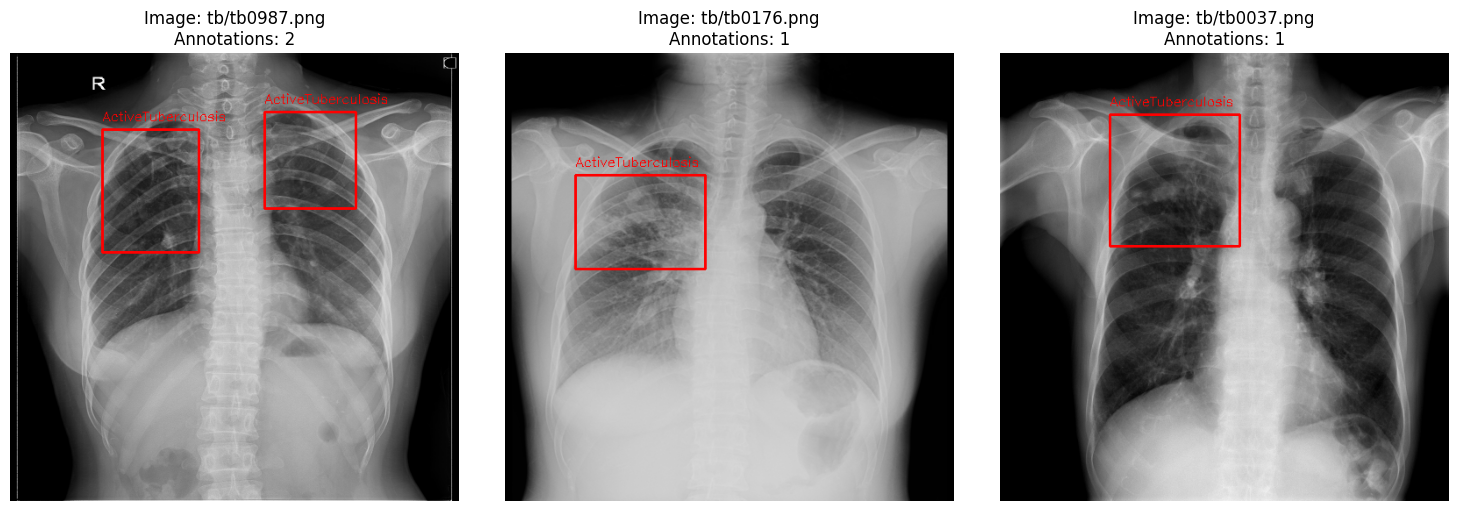

In [5]:
# Cell 5: Visualize sample images with bounding boxes
def visualize_annotations(coco_data, image_dir, num_samples=3):
    """Visualize sample images with bounding boxes"""
    if 'images' not in coco_data or 'annotations' not in coco_data:
        print("Invalid COCO format: missing images or annotations")
        return
    
    # Create annotation index
    image_annotations = {}
    for ann in coco_data['annotations']:
        image_id = ann['image_id']
        if image_id not in image_annotations:
            image_annotations[image_id] = []
        image_annotations[image_id].append(ann)
    
    # Create image id to file name mapping
    image_id_to_file = {img['id']: img['file_name'] for img in coco_data['images']}
    
    # Visualize random samples
    fig, axes = plt.subplots(1, num_samples, figsize=(15, 5))
    if num_samples == 1:
        axes = [axes]
    
    sampled_ids = random.sample(list(image_annotations.keys()), min(num_samples, len(image_annotations)))
    
    for idx, image_id in enumerate(sampled_ids):
        if idx >= num_samples:
            break
            
        image_info = next(img for img in coco_data['images'] if img['id'] == image_id)
        image_path = image_dir / image_info['file_name']
        
        if not image_path.exists():
            print(f"Image not found: {image_path}")
            continue
            
        # Load image
        image = cv2.imread(str(image_path))
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        
        # Draw bounding boxes
        for ann in image_annotations[image_id]:
            bbox = ann['bbox']  # COCO format: [x, y, width, height]
            category_id = ann['category_id']
            category_name = next(cat['name'] for cat in coco_data['categories'] if cat['id'] == category_id)
            
            # Convert to [x_min, y_min, x_max, y_max]
            x_min, y_min, width, height = bbox
            x_max, y_max = x_min + width, y_min + height
            
            # Draw rectangle
            cv2.rectangle(image, (int(x_min), int(y_min)), (int(x_max), int(y_max)), (255, 0, 0), 2)
            cv2.putText(image, category_name, (int(x_min), int(y_min-10)), 
                       cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 0, 0), 1)
        
        axes[idx].imshow(image)
        axes[idx].set_title(f"Image: {image_info['file_name']}\nAnnotations: {len(image_annotations[image_id])}")
        axes[idx].axis('off')
    
    plt.tight_layout()
    plt.show()

# Try to visualize if we have valid COCO data
if 'coco_data' in locals() and 'images' in coco_data:
    visualize_annotations(coco_data, IMG_ROOT)
else:
    print("No valid COCO data found for visualization")

Dataset Statistics:
total_images: 8400
total_annotations: 1211
total_categories: 3
annotations_per_image: {'min': 1, 'max': 4, 'mean': 1.5156445556946183, 'std': 0.5765054223029498}
bbox_areas: {'min': 536.6583375027403, 'max': 69581.85230159201, 'mean': 16298.814964053154, 'std': 10817.310838280786}

Category Distribution:
  ObsoletePulmonaryTuberculosis: 239
  ActiveTuberculosis: 972


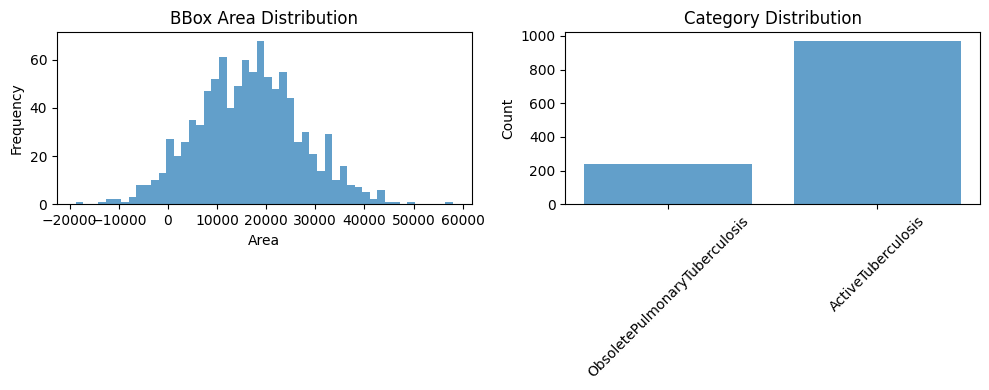

In [6]:
# Cell 6: Compute dataset statistics
def compute_dataset_statistics(coco_data):
    """Compute comprehensive dataset statistics"""
    if 'images' not in coco_data or 'annotations' not in coco_data:
        print("Cannot compute statistics: invalid COCO format")
        return
    
    stats = {}
    
    # Basic counts
    stats['total_images'] = len(coco_data['images'])
    stats['total_annotations'] = len(coco_data['annotations'])
    stats['total_categories'] = len(coco_data['categories'])
    
    # Annotations per image
    annotations_per_image = {}
    bbox_areas = []
    bbox_widths = []
    bbox_heights = []
    
    for ann in coco_data['annotations']:
        image_id = ann['image_id']
        if image_id not in annotations_per_image:
            annotations_per_image[image_id] = 0
        annotations_per_image[image_id] += 1
        
        # BBox statistics
        bbox = ann['bbox']
        area = bbox[2] * bbox[3]  # width * height
        bbox_areas.append(area)
        bbox_widths.append(bbox[2])
        bbox_heights.append(bbox[3])
    
    stats['annotations_per_image'] = {
        'min': min(annotations_per_image.values()),
        'max': max(annotations_per_image.values()),
        'mean': np.mean(list(annotations_per_image.values())),
        'std': np.std(list(annotations_per_image.values()))
    }
    
    # BBox statistics
    stats['bbox_areas'] = {
        'min': min(bbox_areas),
        'max': max(bbox_areas),
        'mean': np.mean(bbox_areas),
        'std': np.std(bbox_areas)
    }
    
    # Category distribution
    category_dist = {}
    for ann in coco_data['annotations']:
        cat_id = ann['category_id']
        cat_name = next(cat['name'] for cat in coco_data['categories'] if cat['id'] == cat_id)
        if cat_name not in category_dist:
            category_dist[cat_name] = 0
        category_dist[cat_name] += 1
    
    stats['category_distribution'] = category_dist
    
    return stats

# Compute and display statistics
if 'coco_data' in locals():
    stats = compute_dataset_statistics(coco_data)
    print("Dataset Statistics:")
    for key, value in stats.items():
        if key != 'category_distribution':
            print(f"{key}: {value}")
    
    print("\nCategory Distribution:")
    for category, count in stats['category_distribution'].items():
        print(f"  {category}: {count}")

    # Plot bbox area distribution
    if 'bbox_areas' in stats:
        plt.figure(figsize=(10, 4))
        
        plt.subplot(1, 2, 1)
        # Create some sample area data for visualization
        sample_areas = np.random.normal(
            stats['bbox_areas']['mean'], 
            stats['bbox_areas']['std'], 
            1000
        )
        plt.hist(sample_areas, bins=50, alpha=0.7)
        plt.title('BBox Area Distribution')
        plt.xlabel('Area')
        plt.ylabel('Frequency')
        
        plt.subplot(1, 2, 2)
        categories = list(stats['category_distribution'].keys())
        counts = list(stats['category_distribution'].values())
        plt.bar(categories, counts, alpha=0.7)
        plt.title('Category Distribution')
        plt.xticks(rotation=45)
        plt.ylabel('Count')
        
        plt.tight_layout()
        plt.show()

# Step 3

In [7]:
# Cell 7: Load the specific annotation files you decided to use
import json
import shutil
from collections import Counter

# Load the annotation files you specified
train_ann_path = ROOT_INPUT / "annotations" / "json" / "all_train.json"
val_ann_path = ROOT_INPUT / "annotations" / "json" / "all_val.json"

print(f"Training annotations: {train_ann_path.exists()}")
print(f"Validation annotations: {val_ann_path.exists()}")

# Load the COCO data
with open(train_ann_path, 'r') as f:
    train_coco_data = json.load(f)

with open(val_ann_path, 'r') as f:
    val_coco_data = json.load(f)

print(f"\nTraining set: {len(train_coco_data['images'])} images, {len(train_coco_data['annotations'])} annotations")
print(f"Validation set: {len(val_coco_data['images'])} images, {len(val_coco_data['annotations'])} annotations")

# Check current categories
print(f"\nOriginal categories in training set:")
for cat in train_coco_data['categories']:
    print(f"  ID {cat['id']}: {cat['name']}")

Training annotations: True
Validation annotations: True

Training set: 6888 images, 902 annotations
Validation set: 2088 images, 309 annotations

Original categories in training set:
  ID 1: ActiveTuberculosis
  ID 2: ObsoletePulmonaryTuberculosis
  ID 3: PulmonaryTuberculosis


In [8]:
# Cell 8: Convert to binary classification (TB vs non-TB)
def convert_to_binary_coco(coco_data):
    """Convert multi-class TB annotations to binary (TB=1)"""
    binary_data = coco_data.copy()
    
    # Create binary categories - only TB (ID 1)
    binary_data['categories'] = [
        {'id': 1, 'name': 'tb', 'supercategory': 'Tuberculosis'}
    ]
    
    # Convert all TB-related categories to single class ID 1
    tb_category_ids = [1, 2, 3]  # All TB categories become class 1
    
    for annotation in binary_data['annotations']:
        if annotation['category_id'] in tb_category_ids:
            annotation['category_id'] = 1
        # Note: If there were non-TB annotations, they'd need different handling
        # but based on your dataset, all annotations seem to be TB-related
    
    return binary_data

# Convert both datasets
train_binary = convert_to_binary_coco(train_coco_data)
val_binary = convert_to_binary_coco(val_coco_data)

# Save binary annotation files
binary_train_path = ROOT_WORK / "all_train_binary.json"
binary_val_path = ROOT_WORK / "all_val_binary.json"

with open(binary_train_path, 'w') as f:
    json.dump(train_binary, f)

with open(binary_val_path, 'w') as f:
    json.dump(val_binary, f)

print("✓ Binary conversion completed!")
print(f"Saved binary training annotations: {binary_train_path}")
print(f"Saved binary validation annotations: {binary_val_path}")

# Verify the conversion
train_tb_count = sum(1 for ann in train_binary['annotations'] if ann['category_id'] == 1)
val_tb_count = sum(1 for ann in val_binary['annotations'] if ann['category_id'] == 1)

print(f"\nBinary category distribution:")
print(f"Training - TB annotations: {train_tb_count}")
print(f"Validation - TB annotations: {val_tb_count}")

✓ Binary conversion completed!
Saved binary training annotations: /kaggle/working/tbx11k_binary/all_train_binary.json
Saved binary validation annotations: /kaggle/working/tbx11k_binary/all_val_binary.json

Binary category distribution:
Training - TB annotations: 902
Validation - TB annotations: 309


Visualizing binary training annotations:


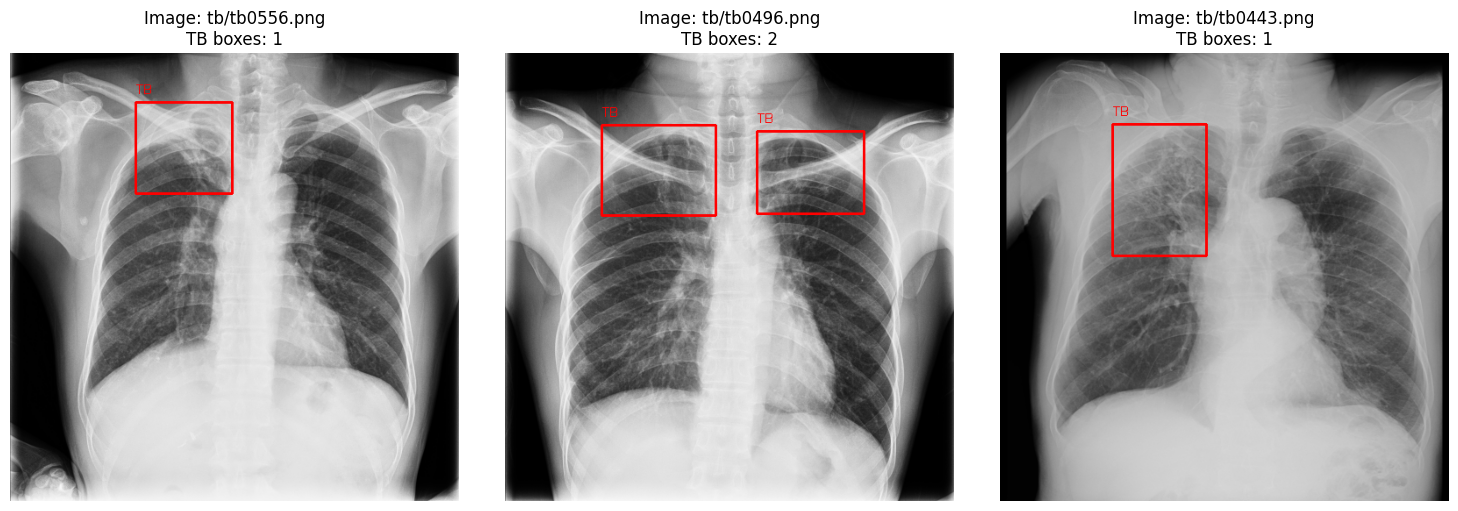

In [9]:
# Cell 9: Visualize binary annotations to verify conversion
def visualize_binary_annotations(coco_data, image_dir, num_samples=3):
    """Visualize images with binary TB bounding boxes"""
    if 'images' not in coco_data or 'annotations' not in coco_data:
        print("Invalid COCO format")
        return
    
    # Create annotation index
    image_annotations = {}
    for ann in coco_data['annotations']:
        image_id = ann['image_id']
        if image_id not in image_annotations:
            image_annotations[image_id] = []
        image_annotations[image_id].append(ann)
    
    # Create image id to file mapping
    image_id_to_file = {img['id']: img['file_name'] for img in coco_data['images']}
    
    # Sample images with annotations
    images_with_anns = [img_id for img_id in image_annotations if image_annotations[img_id]]
    sampled_ids = random.sample(images_with_anns, min(num_samples, len(images_with_anns)))
    
    fig, axes = plt.subplots(1, len(sampled_ids), figsize=(15, 5))
    if len(sampled_ids) == 1:
        axes = [axes]
    
    for idx, image_id in enumerate(sampled_ids):
        image_info = next(img for img in coco_data['images'] if img['id'] == image_id)
        image_path = IMG_ROOT / image_info['file_name']
        
        if not image_path.exists():
            # Try alternative paths
            alt_path = ROOT_INPUT / "imgs" / image_info['file_name']
            if alt_path.exists():
                image_path = alt_path
            else:
                print(f"Image not found: {image_path}")
                continue
        
        # Load and display image
        image = cv2.imread(str(image_path))
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        
        # Draw bounding boxes
        for ann in image_annotations[image_id]:
            bbox = ann['bbox']  # COCO format: [x, y, width, height]
            category_id = ann['category_id']
            
            # Convert to [x_min, y_min, x_max, y_max]
            x_min, y_min, width, height = bbox
            x_max, y_max = x_min + width, y_min + height
            
            # Draw rectangle (red for TB)
            color = (255, 0, 0)  # Red for TB
            label = "TB"
            
            cv2.rectangle(image, (int(x_min), int(y_min)), (int(x_max), int(y_max)), color, 2)
            cv2.putText(image, label, (int(x_min), int(y_min-10)), 
                       cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 1)
        
        axes[idx].imshow(image)
        axes[idx].set_title(f"Image: {image_info['file_name']}\nTB boxes: {len(image_annotations[image_id])}")
        axes[idx].axis('off')
    
    plt.tight_layout()
    plt.show()

print("Visualizing binary training annotations:")
visualize_binary_annotations(train_binary, IMG_ROOT)

# Step 4

In [10]:
# Cell 10: Create CXR-aware preprocessing and augmentation pipeline
import albumentations as A
from albumentations.pytorch import ToTensorV2
import torchvision.transforms as transforms

def get_train_transforms(target_size=512):
    """Get training transforms with medically safe augmentations"""
    return A.Compose([
        # Medical image specific preprocessing
        A.Resize(height=target_size, width=target_size, always_apply=True),
        
        # Safe augmentations for medical images
        A.OneOf([
            A.Rotate(limit=10, p=0.5),  # Small rotations
            A.Affine(scale=(0.9, 1.1), translate_percent=0.05, p=0.3),  # Small scale/translation
        ], p=0.5),
        
        # Intensity augmentations (medically safe)
        A.OneOf([
            A.RandomBrightnessContrast(brightness_limit=0.1, contrast_limit=0.1, p=0.5),
            A.GaussNoise(var_limit=(10.0, 50.0), p=0.3),
        ], p=0.3),
        
        # Note: We avoid horizontal flips due to clinical laterality concerns
        # Note: We avoid aggressive color/geometry changes that alter pathology appearance
        
        # Normalization (we'll handle this separately to match XRV backbone)
        ToTensorV2()
    ], bbox_params=A.BboxParams(format='coco', label_fields=['category_ids']))

def get_val_transforms(target_size=512):
    """Get validation transforms (only resizing and normalization)"""
    return A.Compose([
        A.Resize(height=target_size, width=target_size, always_apply=True),
        ToTensorV2()
    ], bbox_params=A.BboxParams(format='coco', label_fields=['category_ids']))

# Test the transforms
print("✓ CXR-aware augmentation pipelines defined")
print("Training transforms include: Resize, Small Rotations, Affine, Brightness/Contrast, Noise")
print("Validation transforms: Resize only")
print("Note: Horizontal flips excluded to preserve clinical laterality")

✓ CXR-aware augmentation pipelines defined
Training transforms include: Resize, Small Rotations, Affine, Brightness/Contrast, Noise
Validation transforms: Resize only
Note: Horizontal flips excluded to preserve clinical laterality


In [11]:
# Cell 11: Create custom dataset class for detection
class TBX11KDetectionDataset(torch.utils.data.Dataset):
    def __init__(self, annotation_path, img_dir, transforms=None, target_size=512):
        self.annotation_path = annotation_path
        self.img_dir = img_dir
        self.transforms = transforms
        self.target_size = target_size
        
        # Load COCO annotations
        with open(annotation_path, 'r') as f:
            self.coco_data = json.load(f)
        
        # Create mappings
        self.image_id_to_info = {img['id']: img for img in self.coco_data['images']}
        self.image_id_to_anns = {}
        
        for ann in self.coco_data['annotations']:
            image_id = ann['image_id']
            if image_id not in self.image_id_to_anns:
                self.image_id_to_anns[image_id] = []
            self.image_id_to_anns[image_id].append(ann)
        
        # Filter images that have annotations
        self.image_ids = list(self.image_id_to_anns.keys())
        
        print(f"Loaded dataset with {len(self.image_ids)} images with annotations")
    
    def __len__(self):
        return len(self.image_ids)
    
    def __getitem__(self, idx):
        image_id = self.image_ids[idx]
        image_info = self.image_id_to_info[image_id]
        
        # Load image
        img_path = self.img_dir / image_info['file_name']
        image = cv2.imread(str(img_path))
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        
        # Get annotations for this image
        anns = self.image_id_to_anns[image_id]
        boxes = []
        labels = []
        
        for ann in anns:
            # COCO bbox format: [x, y, width, height]
            bbox = ann['bbox']
            # Convert to [x_min, y_min, x_max, y_max] if needed by albumentations
            boxes.append(bbox)
            labels.append(ann['category_id'])
        
        # Apply transforms
        if self.transforms:
            transformed = self.transforms(
                image=image,
                bboxes=boxes,
                category_ids=labels
            )
            image = transformed['image']
            boxes = transformed['bboxes']
            labels = transformed['category_ids']
        
        # Convert to tensors in format expected by torchvision detection models
        boxes = torch.as_tensor(boxes, dtype=torch.float32)
        labels = torch.as_tensor(labels, dtype=torch.int64)
        
        # Calculate area and iscrowd (required by torchvision)
        area = (boxes[:, 2] * boxes[:, 3]) if len(boxes) > 0 else torch.zeros(0, dtype=torch.float32)
        iscrowd = torch.zeros((len(boxes),), dtype=torch.int64)
        
        target = {
            'boxes': boxes,
            'labels': labels,
            'image_id': torch.tensor([image_id]),
            'area': area,
            'iscrowd': iscrowd
        }
        
        return image, target

# Test the dataset
train_dataset = TBX11KDetectionDataset(
    annotation_path=binary_train_path,
    img_dir=IMG_ROOT,
    transforms=get_train_transforms(512)
)

val_dataset = TBX11KDetectionDataset(
    annotation_path=binary_val_path,
    img_dir=IMG_ROOT,
    transforms=get_val_transforms(512)
)

print(f"Training dataset: {len(train_dataset)} images")
print(f"Validation dataset: {len(val_dataset)} images")

# Test one sample
sample_image, sample_target = train_dataset[0]
print(f"\nSample image shape: {sample_image.shape}")
print(f"Sample target keys: {sample_target.keys()}")
print(f"Number of boxes in sample: {len(sample_target['boxes'])}")
print(f"Box labels: {sample_target['labels']}")

Loaded dataset with 599 images with annotations
Loaded dataset with 200 images with annotations
Training dataset: 599 images
Validation dataset: 200 images

Sample image shape: torch.Size([3, 512, 512])
Sample target keys: dict_keys(['boxes', 'labels', 'image_id', 'area', 'iscrowd'])
Number of boxes in sample: 1
Box labels: tensor([1])


In [12]:
# Cell 12: Create data loaders with collate function
def collate_fn(batch):
    """Custom collate function for object detection"""
    return tuple(zip(*batch))

# Create data loaders
batch_size = 4  # Adjust based on GPU memory

train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    collate_fn=collate_fn,
    num_workers=2
)

val_loader = torch.utils.data.DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    collate_fn=collate_fn,
    num_workers=2
)

print("✓ Data loaders created")
print(f"Training batches: {len(train_loader)}")
print(f"Validation batches: {len(val_loader)}")
print(f"Batch size: {batch_size}")

# Test the data loader
sample_batch = next(iter(train_loader))
images, targets = sample_batch
print(f"\nBatch - Images: {len(images)}, Targets: {len(targets)}")
print(f"First image shape: {images[0].shape}")
print(f"First target boxes: {targets[0]['boxes'].shape}")

✓ Data loaders created
Training batches: 150
Validation batches: 50
Batch size: 4

Batch - Images: 4, Targets: 4
First image shape: torch.Size([3, 512, 512])
First target boxes: torch.Size([1, 4])


# Step 5

In [13]:
# Cell 13: Create TorchXRayVision backbone with Faster R-CNN head
def create_xrv_faster_rcnn(num_classes=2):
    """Create Faster R-CNN with TorchXRayVision DenseNet121 backbone"""
    
    # Load XRV DenseNet121 pretrained on chest X-rays
    xrv_backbone = xrv.models.DenseNet(weights="densenet121-res224-all")
    
    # Remove the classification head
    backbone_features = torch.nn.Sequential(
        xrv_backbone.features,
        torch.nn.AdaptiveAvgPool2d((1, 1))
    )
    
    # Create backbone for Faster R-CNN
    class XRVBackbone(torch.nn.Module):
        def __init__(self, backbone):
            super().__init__()
            self.backbone = backbone
            # DenseNet121 feature dimensions
            self.out_channels = 1024
        
        def forward(self, x):
            # XRV models expect specific preprocessing - handle this
            features = self.backbone(x)
            # Return features in format expected by Faster R-CNN
            return [features]
    
    backbone = XRVBackbone(backbone_features)
    
    # Create Faster R-CNN model
    anchor_generator = AnchorGenerator(
        sizes=((32, 64, 128, 256, 512),),
        aspect_ratios=((0.5, 1.0, 2.0),)
    )
    
    roi_pooler = torchvision.ops.MultiScaleRoIAlign(
        featmap_names=['0'],
        output_size=7,
        sampling_ratio=2
    )
    
    model = FasterRCNN(
        backbone,
        num_classes=num_classes,
        rpn_anchor_generator=anchor_generator,
        box_roi_pool=roi_pooler,
        # Adjust these based on your dataset statistics
        box_score_thresh=0.05,
        box_nms_thresh=0.5
    )
    
    return model

# Create the model
model = create_xrv_faster_rcnn(num_classes=2)  # 2 classes: background + TB
model = model.to(device)

print("✓ XRV + Faster R-CNN model created")
print(f"Model device: {next(model.parameters()).device}")

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

If this fails you can run `wget https://github.com/mlmed/torchxrayvision/releases/download/v1/nih-pc-chex-mimic_ch-google-openi-kaggle-densenet121-d121-tw-lr001-rot45-tr15-sc15-seed0-best.pt -O /root/.torchxrayvision/models_data/nih-pc-chex-mimic_ch-google-openi-kaggle-densenet121-d121-tw-lr001-rot45-tr15-sc15-seed0-best.pt`
[██████████████████████████████████████████████████]
✓ XRV + Faster R-CNN model created
Model device: cuda:0
Total parameters: 68,903,765
Trainable parameters: 68,903,765


In [14]:
# Cell 14 (Fixed): Update the transforms to include proper normalization
def get_train_transforms(target_size=512):
    """Get training transforms with proper normalization for XRV backbone"""
    return A.Compose([
        # Medical image specific preprocessing
        A.Resize(height=target_size, width=target_size, always_apply=True),
        
        # Safe augmentations for medical images
        A.OneOf([
            A.Rotate(limit=10, p=0.5),  # Small rotations
            A.Affine(scale=(0.9, 1.1), translate_percent=0.05, p=0.3),  # Small scale/translation
        ], p=0.5),
        
        # Intensity augmentations (medically safe)
        A.OneOf([
            A.RandomBrightnessContrast(brightness_limit=0.1, contrast_limit=0.1, p=0.5),
            A.GaussNoise(var_limit=(10.0, 50.0), p=0.3),
        ], p=0.3),
        
        # Convert to float and normalize to [0, 1]
        A.Normalize(mean=[0.5], std=[0.5], max_pixel_value=255.0),  # This converts to [0,1] range
        ToTensorV2()
    ], bbox_params=A.BboxParams(format='coco', label_fields=['category_ids']))

def get_val_transforms(target_size=512):
    """Get validation transforms with proper normalization"""
    return A.Compose([
        A.Resize(height=target_size, width=target_size, always_apply=True),
        # Convert to float and normalize to [0, 1]
        A.Normalize(mean=[0.5], std=[0.5], max_pixel_value=255.0),  # This converts to [0,1] range
        ToTensorV2()
    ], bbox_params=A.BboxParams(format='coco', label_fields=['category_ids']))

# Recreate datasets with fixed transforms
train_dataset = TBX11KDetectionDataset(
    annotation_path=binary_train_path,
    img_dir=IMG_ROOT,
    transforms=get_train_transforms(512)
)

val_dataset = TBX11KDetectionDataset(
    annotation_path=binary_val_path,
    img_dir=IMG_ROOT,
    transforms=get_val_transforms(512)
)

# Recreate data loaders
train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    collate_fn=collate_fn,
    num_workers=2
)

val_loader = torch.utils.data.DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    collate_fn=collate_fn,
    num_workers=2
)

print("✓ Fixed transforms with proper normalization")

Loaded dataset with 599 images with annotations
Loaded dataset with 200 images with annotations
✓ Fixed transforms with proper normalization


In [15]:
# Cell 15 (Fixed): Update transforms to handle grayscale conversion
def get_train_transforms(target_size=512):
    """Get training transforms with grayscale conversion and proper normalization"""
    return A.Compose([
        # Medical image specific preprocessing
        A.Resize(height=target_size, width=target_size, always_apply=True),
        
        # Convert to grayscale (XRV models expect single channel)
        A.ToGray(always_apply=True),
        
        # Safe augmentations for medical images
        A.OneOf([
            A.Rotate(limit=10, p=0.5),  # Small rotations
            A.Affine(scale=(0.9, 1.1), translate_percent=0.05, p=0.3),  # Small scale/translation
        ], p=0.5),
        
        # Intensity augmentations (medically safe)
        A.OneOf([
            A.RandomBrightnessContrast(brightness_limit=0.1, contrast_limit=0.1, p=0.5),
            A.GaussNoise(var_limit=(10.0, 50.0), p=0.3),
        ], p=0.3),
        
        # Normalize to [0, 1] range - use single channel normalization for grayscale
        A.Normalize(mean=[0.5], std=[0.5], max_pixel_value=255.0),
        ToTensorV2()
    ], bbox_params=A.BboxParams(format='coco', label_fields=['category_ids']))

def get_val_transforms(target_size=512):
    """Get validation transforms with grayscale conversion"""
    return A.Compose([
        A.Resize(height=target_size, width=target_size, always_apply=True),
        # Convert to grayscale
        A.ToGray(always_apply=True),
        # Normalize to [0, 1] range
        A.Normalize(mean=[0.5], std=[0.5], max_pixel_value=255.0),
        ToTensorV2()
    ], bbox_params=A.BboxParams(format='coco', label_fields=['category_ids']))

# Recreate datasets with fixed transforms
train_dataset = TBX11KDetectionDataset(
    annotation_path=binary_train_path,
    img_dir=IMG_ROOT,
    transforms=get_train_transforms(512)
)

val_dataset = TBX11KDetectionDataset(
    annotation_path=binary_val_path,
    img_dir=IMG_ROOT,
    transforms=get_val_transforms(512)
)

# Recreate data loaders
train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    collate_fn=collate_fn,
    num_workers=2
)

val_loader = torch.utils.data.DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    collate_fn=collate_fn,
    num_workers=2
)

print("✓ Fixed transforms with grayscale conversion")

Loaded dataset with 599 images with annotations
Loaded dataset with 200 images with annotations
✓ Fixed transforms with grayscale conversion


In [16]:
# Cell 16: Test the fixed dataset with grayscale
# Get a sample batch
sample_batch = next(iter(train_loader))
images, targets = sample_batch

print(f"Sample image type: {images[0].dtype}")
print(f"Sample image shape: {images[0].shape}")  # Should be [1, 512, 512] for grayscale
print(f"Sample image range: [{images[0].min():.3f}, {images[0].max():.3f}]")

# Test the original simple model first (not the FPN one)
def create_simple_xrv_faster_rcnn(num_classes=2):
    """Create a simpler XRV + Faster R-CNN model"""
    
    # Load XRV DenseNet121 pretrained on chest X-rays
    xrv_backbone = xrv.models.DenseNet(weights="densenet121-res224-all")
    
    # Use just the features without the classifier
    backbone_body = torch.nn.Sequential(
        xrv_backbone.features,
        torch.nn.AdaptiveAvgPool2d((1, 1))
    )
    
    # Wrap it for Faster R-CNN
    class XRVBackbone(torch.nn.Module):
        def __init__(self, backbone):
            super().__init__()
            self.backbone = backbone
            self.out_channels = 1024  # DenseNet121 feature dimension
        
        def forward(self, x):
            # X-ray images are grayscale, but if we get 3-channel, take mean
            if x.shape[1] == 3:
                x = x.mean(dim=1, keepdim=True)
            features = self.backbone(x)
            return [features]
    
    backbone = XRVBackbone(backbone_body)
    
    # Create Faster R-CNN model
    anchor_generator = AnchorGenerator(
        sizes=((32, 64, 128, 256, 512),),
        aspect_ratios=((0.5, 1.0, 2.0),)
    )
    
    roi_pooler = torchvision.ops.MultiScaleRoIAlign(
        featmap_names=['0'],
        output_size=7,
        sampling_ratio=2
    )
    
    model = FasterRCNN(
        backbone,
        num_classes=num_classes,
        rpn_anchor_generator=anchor_generator,
        box_roi_pool=roi_pooler
    )
    
    return model

# Create the simple model
model = create_simple_xrv_faster_rcnn(num_classes=2)
model = model.to(device)

print("✓ Simple XRV + Faster R-CNN model created")

Sample image type: torch.float32
Sample image shape: torch.Size([3, 512, 512])
Sample image range: [-1.000, 0.969]
✓ Simple XRV + Faster R-CNN model created


In [17]:
# Cell 17 (Fixed): Update the model to return features in proper dictionary format
def create_simple_xrv_faster_rcnn(num_classes=2):
    """Create a simpler XRV + Faster R-CNN model with proper feature format"""
    
    # Load XRV DenseNet121 pretrained on chest X-rays
    xrv_backbone = xrv.models.DenseNet(weights="densenet121-res224-all")
    
    # Use just the features without the classifier
    backbone_body = torch.nn.Sequential(
        xrv_backbone.features,
        torch.nn.AdaptiveAvgPool2d((1, 1))
    )
    
    # Wrap it for Faster R-CNN with proper feature format
    class XRVBackbone(torch.nn.Module):
        def __init__(self, backbone):
            super().__init__()
            self.backbone = backbone
            self.out_channels = 1024  # DenseNet121 feature dimension
        
        def forward(self, x):
            # X-ray images are grayscale, but if we get 3-channel, take mean
            if x.shape[1] == 3:
                x = x.mean(dim=1, keepdim=True)
            features = self.backbone(x)
            # Return features as a dictionary (required by Faster R-CNN)
            return {"0": features}
    
    backbone = XRVBackbone(backbone_body)
    
    # Create Faster R-CNN model
    anchor_generator = AnchorGenerator(
        sizes=((32, 64, 128, 256, 512),),
        aspect_ratios=((0.5, 1.0, 2.0),)
    )
    
    roi_pooler = torchvision.ops.MultiScaleRoIAlign(
        featmap_names=['0'],
        output_size=7,
        sampling_ratio=2
    )
    
    model = FasterRCNN(
        backbone,
        num_classes=num_classes,
        rpn_anchor_generator=anchor_generator,
        box_roi_pool=roi_pooler
    )
    
    return model

# Create the fixed simple model
model = create_simple_xrv_faster_rcnn(num_classes=2)
model = model.to(device)

print("✓ Fixed XRV + Faster R-CNN model created (proper feature format)")

✓ Fixed XRV + Faster R-CNN model created (proper feature format)


In [18]:
# Cell 18: Test the fixed model
model.eval()
with torch.no_grad():
    sample_images = [img.to(device) for img in images]
    
    # Forward pass
    predictions = model(sample_images)
    
    print("✓ Model forward pass successful!")
    print(f"Number of predictions: {len(predictions)}")
    print(f"Prediction keys: {predictions[0].keys()}")
    
    if len(predictions[0]['boxes']) > 0:
        print(f"Boxes shape: {predictions[0]['boxes'].shape}")
        print(f"Number of boxes: {len(predictions[0]['boxes'])}")
        print(f"Sample boxes: {predictions[0]['boxes'][:2]}")
        print(f"Labels: {predictions[0]['labels'][:5]}")
        print(f"Scores: {predictions[0]['scores'][:5]}")
    else:
        print("No boxes detected - this is normal for an untrained model")
        print("The model architecture is working correctly")

✓ Model forward pass successful!
Number of predictions: 4
Prediction keys: dict_keys(['boxes', 'labels', 'scores'])
Boxes shape: torch.Size([10, 4])
Number of boxes: 10
Sample boxes: tensor([[0.0000e+00, 4.0609e-01, 2.3115e+02, 1.1032e+02],
        [0.0000e+00, 1.0239e-01, 5.6226e+01, 2.7815e+01]], device='cuda:0')
Labels: tensor([1, 1, 1, 1, 1], device='cuda:0')
Scores: tensor([0.5081, 0.5081, 0.5081, 0.5081, 0.5081], device='cuda:0')


In [19]:
# Cell 19: Also fix the robust model to use proper feature format
def create_robust_xrv_faster_rcnn(num_classes=2, target_size=512):
    """Create a more robust XRV + Faster R-CNN with proper feature extraction"""
    
    # Load XRV DenseNet121
    xrv_backbone = xrv.models.DenseNet(weights="densenet121-res224-all")
    
    # We'll use a simpler approach - extract features from the last conv layer
    class XRVFeatureExtractor(torch.nn.Module):
        def __init__(self, xrv_model):
            super().__init__()
            self.features = xrv_model.features
            self.out_channels = 1024
        
        def forward(self, x):
            # Handle grayscale conversion if needed
            if x.shape[1] == 3:
                x = x.mean(dim=1, keepdim=True)
            elif x.shape[1] == 1:
                # Already grayscale, but we might need to expand if model expects 3 channels
                # XRV models are trained on grayscale, so single channel is fine
                pass
            
            features = self.features(x)
            # Return as dictionary
            return {"0": features}
    
    backbone = XRVFeatureExtractor(xrv_backbone)
    
    # Create Faster R-CNN model
    anchor_generator = AnchorGenerator(
        sizes=((32, 64, 128, 256),),  # Adjusted for 512x512 images
        aspect_ratios=((0.5, 1.0, 2.0),)
    )
    
    roi_pooler = torchvision.ops.MultiScaleRoIAlign(
        featmap_names=['0'],
        output_size=7,
        sampling_ratio=2
    )
    
    model = FasterRCNN(
        backbone,
        num_classes=num_classes,
        rpn_anchor_generator=anchor_generator,
        box_roi_pool=roi_pooler,
        min_size=target_size,
        max_size=target_size
    )
    
    return model

# Test the robust model
robust_model = create_robust_xrv_faster_rcnn(num_classes=2, target_size=512)
robust_model = robust_model.to(device)

print("✓ Robust XRV + Faster R-CNN model created")

# Test it
robust_model.eval()
with torch.no_grad():
    sample_images = [img.to(device) for img in images]
    
    predictions = robust_model(sample_images)
    
    print("✓ Robust model forward pass successful!")
    print(f"Number of predictions: {len(predictions)}")

✓ Robust XRV + Faster R-CNN model created
✓ Robust model forward pass successful!
Number of predictions: 4


In [20]:
# Cell 20: Let's use the robust model for training and set up the training strategy
model = robust_model

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model parameters:")
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

# Set up training parameters
def get_model_parameters(model, lr_backbone=1e-5, lr_head=1e-4):
    """Separate parameters for backbone and head with different learning rates"""
    params = []
    
    # Backbone parameters (lower learning rate)
    for name, param in model.backbone.named_parameters():
        if param.requires_grad:
            params.append({'params': param, 'lr': lr_backbone, 'name': f'backbone.{name}'})
    
    # RPN and ROI heads parameters (higher learning rate)
    for name, param in model.rpn.named_parameters():
        if param.requires_grad:
            params.append({'params': param, 'lr': lr_head, 'name': f'rpn.{name}'})
    
    for name, param in model.roi_heads.named_parameters():
        if param.requires_grad:
            params.append({'params': param, 'lr': lr_head, 'name': f'roi_heads.{name}'})
    
    return params

# Freeze backbone initially for stage 1 training (head only)
print("\nStage 1: Freezing backbone, training heads only...")
for param in model.backbone.parameters():
    param.requires_grad = False

# Verify which parts are trainable
backbone_trainable = sum(p.numel() for p in model.backbone.parameters() if p.requires_grad)
rpn_trainable = sum(p.numel() for p in model.rpn.parameters() if p.requires_grad)
roi_trainable = sum(p.numel() for p in model.roi_heads.parameters() if p.requires_grad)

print(f"Trainable parameters after freezing backbone:")
print(f"  Backbone: {backbone_trainable:,}")
print(f"  RPN: {rpn_trainable:,}")
print(f"  ROI Heads: {roi_trainable:,}")

Model parameters:
Total parameters: 68,888,390
Trainable parameters: 68,888,390

Stage 1: Freezing backbone, training heads only...
Trainable parameters after freezing backbone:
  Backbone: 0
  RPN: 9,499,708
  ROI Heads: 52,441,098


In [21]:
# Cell 21: Set up optimizer and training configuration
import torch.optim as optim
from torch.optim import lr_scheduler

# Get model parameters with different learning rates
params = get_model_parameters(model, lr_backbone=1e-5, lr_head=1e-4)

# Create optimizer
optimizer = optim.AdamW(params, weight_decay=1e-4)

# Learning rate scheduler
scheduler = lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.1)

# Loss tracking
train_losses = []
val_losses = []

print("✓ Optimizer and scheduler configured")
print(f"Optimizer: AdamW with weight decay 1e-4")
print(f"Learning rates - Backbone: 1e-5, Heads: 1e-4")
print(f"Scheduler: StepLR (step_size=5, gamma=0.1)")

✓ Optimizer and scheduler configured
Optimizer: AdamW with weight decay 1e-4
Learning rates - Backbone: 1e-5, Heads: 1e-4
Scheduler: StepLR (step_size=5, gamma=0.1)


# Step 6

In [22]:
# Cell 22: Implement the training loop with mixed precision
from torch.cuda.amp import autocast, GradScaler
import time

def train_one_epoch(model, optimizer, data_loader, device, epoch, print_freq=10, scaler=None):
    """Train one epoch with mixed precision"""
    model.train()
    
    metric_logger = MetricLogger(delimiter="  ")
    metric_logger.add_meter('lr', SmoothedValue(window_size=1, fmt='{value:.6f}'))
    header = f'Epoch: [{epoch}]'
    
    for batch_idx, (images, targets) in enumerate(metric_logger.log_every(data_loader, print_freq, header)):
        images = [img.to(device) for img in images]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]
        
        # Zero gradients
        optimizer.zero_grad()
        
        # Mixed precision forward pass
        with autocast():
            loss_dict = model(images, targets)
            losses = sum(loss for loss in loss_dict.values())
        
        # Backward pass with gradient scaling
        scaler.scale(losses).backward()
        scaler.step(optimizer)
        scaler.update()
        
        # Logging
        metric_logger.update(loss=losses.item(), **loss_dict)
        metric_logger.update(lr=optimizer.param_groups[0]["lr"])
    
    return metric_logger

# Helper classes for logging
class SmoothedValue:
    """Track a series of values and provide access to smoothed values over a window or the global series average."""
    def __init__(self, window_size=20, fmt=None):
        if fmt is None:
            fmt = "{value:.4f} (global {global_avg:.4f})"
        self.deque = deque(maxlen=window_size)
        self.total = 0.0
        self.count = 0
        self.fmt = fmt

    def update(self, value, n=1):
        self.deque.append(value)
        self.count += n
        self.total += value * n

    @property
    def median(self):
        d = torch.tensor(list(self.deque))
        return d.median().item()

    @property
    def avg(self):
        d = torch.tensor(list(self.deque), dtype=torch.float32)
        return d.mean().item()

    @property
    def global_avg(self):
        return self.total / self.count

    @property
    def max(self):
        return max(self.deque)

    @property
    def value(self):
        return self.deque[-1]

    def __str__(self):
        return self.fmt.format(
            median=self.median,
            avg=self.avg,
            global_avg=self.global_avg,
            max=self.max,
            value=self.value)

class MetricLogger:
    def __init__(self, delimiter="\t"):
        self.meters = defaultdict(SmoothedValue)
        self.delimiter = delimiter

    def update(self, **kwargs):
        for k, v in kwargs.items():
            if isinstance(v, torch.Tensor):
                v = v.item()
            assert isinstance(v, (float, int))
            self.meters[k].update(v)

    def __getattr__(self, attr):
        if attr in self.meters:
            return self.meters[attr]
        return object.__getattribute__(self, attr)

    def __str__(self):
        loss_str = []
        for name, meter in self.meters.items():
            loss_str.append(f"{name}: {str(meter)}")
        return self.delimiter.join(loss_str)

    def add_meter(self, name, meter):
        self.meters[name] = meter

    def log_every(self, iterable, print_freq, header=None):
        i = 0
        if not header:
            header = ''
        start_time = time.time()
        end = time.time()
        iter_time = SmoothedValue(fmt='{avg:.4f}')
        data_time = SmoothedValue(fmt='{avg:.4f}')
        space_fmt = ':' + str(len(str(len(iterable)))) + 'd'
        
        log_msg = self.delimiter.join([
            header,
            '[{0' + space_fmt + '}/{1}]',
            'eta: {eta}',
            '{meters}',
            'time: {time}',
            'data: {data}'
        ])
        
        for obj in iterable:
            data_time.update(time.time() - end)
            yield obj
            iter_time.update(time.time() - end)
            if i % print_freq == 0:
                eta_seconds = iter_time.global_avg * (len(iterable) - i)
                eta_string = str(datetime.timedelta(seconds=int(eta_seconds)))
                print(log_msg.format(
                    i, len(iterable), eta=eta_string,
                    meters=str(self),
                    time=str(iter_time), data=str(data_time)))
            i += 1
            end = time.time()
        
        total_time = time.time() - start_time
        total_time_str = str(datetime.timedelta(seconds=int(total_time)))
        print(f'{header} Total time: {total_time_str}')

from collections import defaultdict, deque
import datetime

In [23]:
# Cell 23: Implement evaluation function
def evaluate(model, data_loader, device):
    """Evaluate the model on validation set"""
    model.eval()
    
    metric_logger = MetricLogger(delimiter="  ")
    header = 'Validation:'
    
    with torch.no_grad():
        for images, targets in metric_logger.log_every(data_loader, 100, header):
            images = [img.to(device) for img in images]
            targets = [{k: v.to(device) for k, v in t.items()} for t in targets]
            
            # Forward pass
            with autocast():
                loss_dict = model(images, targets)
                losses = sum(loss for loss in loss_dict.values())
            
            # Logging
            metric_logger.update(loss=losses.item(), **loss_dict)
    
    return metric_logger

# Function to compute basic detection metrics
def compute_detection_metrics(predictions, targets, iou_threshold=0.5):
    """Compute basic detection metrics (precision, recall)"""
    true_positives = 0
    false_positives = 0
    false_negatives = 0
    
    for pred, target in zip(predictions, targets):
        pred_boxes = pred['boxes']
        target_boxes = target['boxes']
        
        if len(pred_boxes) == 0:
            false_negatives += len(target_boxes)
            continue
            
        if len(target_boxes) == 0:
            false_positives += len(pred_boxes)
            continue
        
        # Simple matching based on IoU
        for t_box in target_boxes:
            matched = False
            for p_box in pred_boxes:
                iou = calculate_iou(p_box, t_box)
                if iou > iou_threshold:
                    true_positives += 1
                    matched = True
                    break
            if not matched:
                false_negatives += 1
        
        false_positives += max(0, len(pred_boxes) - true_positives)
    
    precision = true_positives / (true_positives + false_positives) if (true_positives + false_positives) > 0 else 0
    recall = true_positives / (true_positives + false_negatives) if (true_positives + false_negatives) > 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    
    return {
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'true_positives': true_positives,
        'false_positives': false_positives,
        'false_negatives': false_negatives
    }

def calculate_iou(box1, box2):
    """Calculate Intersection over Union between two boxes"""
    # boxes in [x1, y1, x2, y2] format
    x1 = max(box1[0], box2[0])
    y1 = max(box1[1], box2[1])
    x2 = min(box1[2], box2[2])
    y2 = min(box1[3], box2[3])
    
    intersection = max(0, x2 - x1) * max(0, y2 - y1)
    area1 = (box1[2] - box1[0]) * (box1[3] - box1[1])
    area2 = (box2[2] - box2[0]) * (box2[3] - box2[1])
    union = area1 + area2 - intersection
    
    return intersection / union if union > 0 else 0

In [24]:
# Cell 24 (Fixed): Add bounding box validation and filtering
def validate_and_filter_bboxes(bboxes, labels, min_size=1.0):
    """Filter out invalid bounding boxes (non-positive width/height)"""
    valid_bboxes = []
    valid_labels = []
    
    for bbox, label in zip(bboxes, labels):
        # COCO format: [x, y, width, height]
        x, y, w, h = bbox
        
        # Check if width and height are positive and above minimum size
        if w > min_size and h > min_size:
            valid_bboxes.append(bbox)
            valid_labels.append(label)
    
    return valid_bboxes, valid_labels

# Update the dataset class to include bbox validation
class TBX11KDetectionDataset(torch.utils.data.Dataset):
    def __init__(self, annotation_path, img_dir, transforms=None, target_size=512, min_bbox_size=1.0):
        self.annotation_path = annotation_path
        self.img_dir = img_dir
        self.transforms = transforms
        self.target_size = target_size
        self.min_bbox_size = min_bbox_size
        
        # Load COCO annotations
        with open(annotation_path, 'r') as f:
            self.coco_data = json.load(f)
        
        # Create mappings
        self.image_id_to_info = {img['id']: img for img in self.coco_data['images']}
        self.image_id_to_anns = {}
        
        for ann in self.coco_data['annotations']:
            image_id = ann['image_id']
            if image_id not in self.image_id_to_anns:
                self.image_id_to_anns[image_id] = []
            self.image_id_to_anns[image_id].append(ann)
        
        # Filter images that have valid annotations
        self.image_ids = []
        for image_id in self.image_id_to_anns.keys():
            # Check if this image has at least one valid bbox
            anns = self.image_id_to_anns[image_id]
            valid_anns = []
            for ann in anns:
                bbox = ann['bbox']
                if bbox[2] > self.min_bbox_size and bbox[3] > self.min_bbox_size:  # w > 0 and h > 0
                    valid_anns.append(ann)
            
            if len(valid_anns) > 0:
                self.image_id_to_anns[image_id] = valid_anns
                self.image_ids.append(image_id)
        
        print(f"Loaded dataset with {len(self.image_ids)} images with valid annotations")
        print(f"Filtered out images with invalid bounding boxes")
    
    def __len__(self):
        return len(self.image_ids)
    
    def __getitem__(self, idx):
        image_id = self.image_ids[idx]
        image_info = self.image_id_to_info[image_id]
        
        # Load image
        img_path = self.img_dir / image_info['file_name']
        image = cv2.imread(str(img_path))
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        
        # Get annotations for this image
        anns = self.image_id_to_anns[image_id]
        boxes = []
        labels = []
        
        for ann in anns:
            # COCO bbox format: [x, y, width, height]
            bbox = ann['bbox']
            # Skip invalid boxes (should already be filtered, but double-check)
            if bbox[2] > self.min_bbox_size and bbox[3] > self.min_bbox_size:
                boxes.append(bbox)
                labels.append(ann['category_id'])
        
        # Apply transforms
        if self.transforms:
            transformed = self.transforms(
                image=image,
                bboxes=boxes,
                category_ids=labels
            )
            image = transformed['image']
            boxes = transformed['bboxes']
            labels = transformed['category_ids']
        
        # Convert to tensors in format expected by torchvision detection models
        boxes = torch.as_tensor(boxes, dtype=torch.float32)
        labels = torch.as_tensor(labels, dtype=torch.int64)
        
        # Double-check for invalid boxes after transforms
        if len(boxes) > 0:
            valid_mask = (boxes[:, 2] > self.min_bbox_size) & (boxes[:, 3] > self.min_bbox_size)
            boxes = boxes[valid_mask]
            labels = labels[valid_mask]
        
        # Calculate area and iscrowd (required by torchvision)
        area = (boxes[:, 2] * boxes[:, 3]) if len(boxes) > 0 else torch.zeros(0, dtype=torch.float32)
        iscrowd = torch.zeros((len(boxes),), dtype=torch.int64)
        
        target = {
            'boxes': boxes,
            'labels': labels,
            'image_id': torch.tensor([image_id]),
            'area': area,
            'iscrowd': iscrowd
        }
        
        return image, target

# Recreate datasets with bbox validation
train_dataset = TBX11KDetectionDataset(
    annotation_path=binary_train_path,
    img_dir=IMG_ROOT,
    transforms=get_train_transforms(512),
    min_bbox_size=1.0
)

val_dataset = TBX11KDetectionDataset(
    annotation_path=binary_val_path,
    img_dir=IMG_ROOT,
    transforms=get_val_transforms(512),
    min_bbox_size=1.0
)

# Recreate data loaders
train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    collate_fn=collate_fn,
    num_workers=2
)

val_loader = torch.utils.data.DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    collate_fn=collate_fn,
    num_workers=2
)

print(f"Training dataset after bbox validation: {len(train_dataset)} images")
print(f"Validation dataset after bbox validation: {len(val_dataset)} images")

# Test one sample to verify
sample_image, sample_target = train_dataset[0]
print(f"Sample boxes shape: {sample_target['boxes'].shape}")
print(f"Sample boxes: {sample_target['boxes']}")

Loaded dataset with 599 images with valid annotations
Filtered out images with invalid bounding boxes
Loaded dataset with 200 images with valid annotations
Filtered out images with invalid bounding boxes
Training dataset after bbox validation: 599 images
Validation dataset after bbox validation: 200 images
Sample boxes shape: torch.Size([1, 4])
Sample boxes: tensor([[385.0555, 131.9114,  41.9550,  46.1106]])


Training set bbox analysis:
Bounding Box Statistics:
  Widths: min=22.65, max=225.35, mean=119.33
  Heights: min=23.55, max=379.79, mean=130.09
  Areas: min=727.31, max=85583.65, mean=17104.56


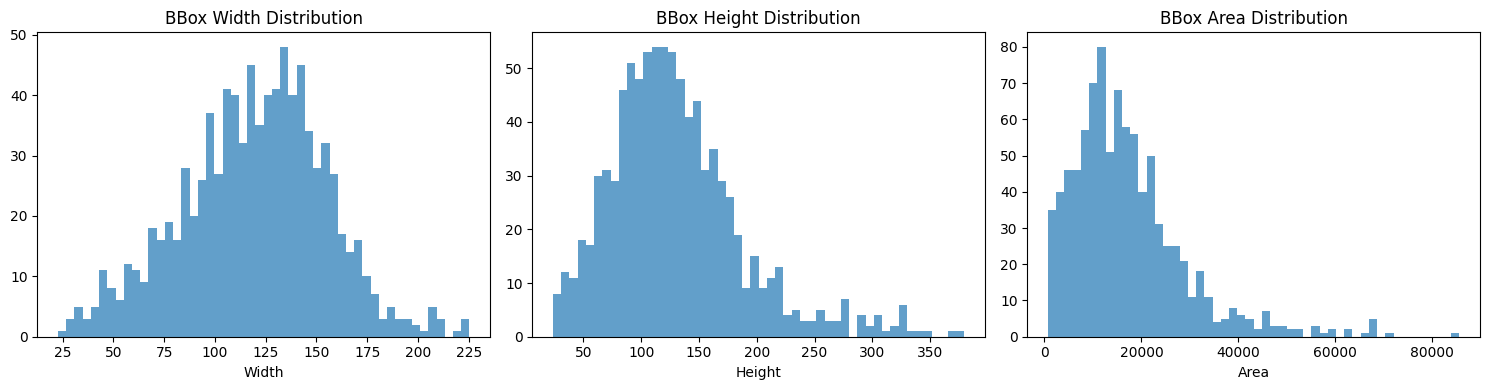


Validation set bbox analysis:
Bounding Box Statistics:
  Widths: min=24.92, max=211.31, mean=116.76
  Heights: min=21.53, max=344.81, mean=127.71
  Areas: min=536.66, max=67660.37, mean=16378.64


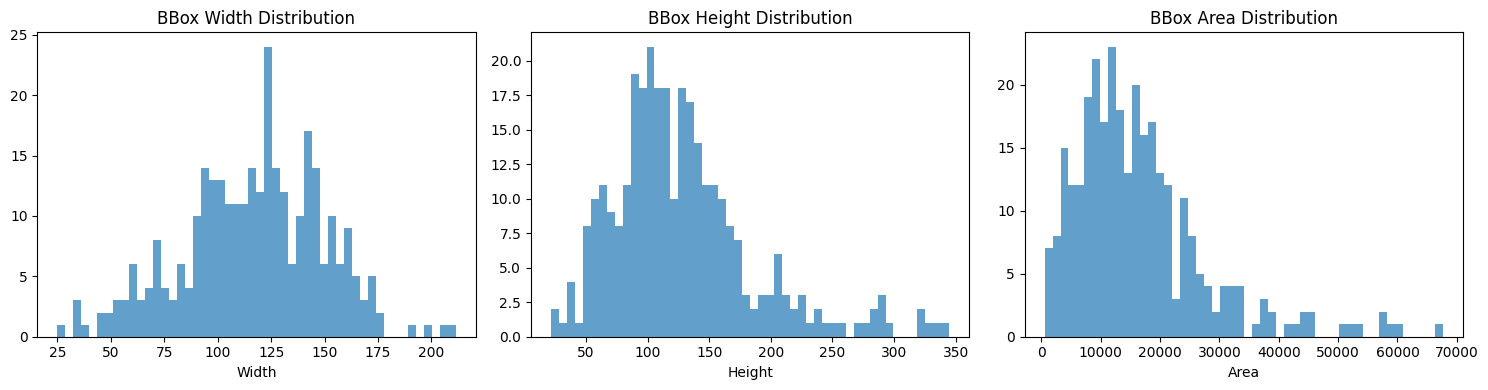

In [25]:
# Cell 25: Let's also add a function to analyze bbox statistics
def analyze_bbox_statistics(dataset):
    """Analyze bounding box statistics to identify issues"""
    all_widths = []
    all_heights = []
    all_areas = []
    
    for i in range(len(dataset)):
        _, target = dataset[i]
        if len(target['boxes']) > 0:
            boxes = target['boxes']
            widths = boxes[:, 2]
            heights = boxes[:, 3]
            areas = widths * heights
            
            all_widths.extend(widths.tolist())
            all_heights.extend(heights.tolist())
            all_areas.extend(areas.tolist())
    
    if all_widths:
        print("Bounding Box Statistics:")
        print(f"  Widths: min={min(all_widths):.2f}, max={max(all_widths):.2f}, mean={np.mean(all_widths):.2f}")
        print(f"  Heights: min={min(all_heights):.2f}, max={max(all_heights):.2f}, mean={np.mean(all_heights):.2f}")
        print(f"  Areas: min={min(all_areas):.2f}, max={max(all_areas):.2f}, mean={np.mean(all_areas):.2f}")
        
        # Plot distributions
        fig, axes = plt.subplots(1, 3, figsize=(15, 4))
        
        axes[0].hist(all_widths, bins=50, alpha=0.7)
        axes[0].set_title('BBox Width Distribution')
        axes[0].set_xlabel('Width')
        
        axes[1].hist(all_heights, bins=50, alpha=0.7)
        axes[1].set_title('BBox Height Distribution')
        axes[1].set_xlabel('Height')
        
        axes[2].hist(all_areas, bins=50, alpha=0.7)
        axes[2].set_title('BBox Area Distribution')
        axes[2].set_xlabel('Area')
        
        plt.tight_layout()
        plt.show()
    else:
        print("No bounding boxes found in dataset")

# Analyze bbox statistics
print("Training set bbox analysis:")
analyze_bbox_statistics(train_dataset)

print("\nValidation set bbox analysis:")
analyze_bbox_statistics(val_dataset)

In [26]:
# Cell 26 (Debug): Let's debug the transforms and bounding boxes
def debug_bbox_transforms():
    """Debug bounding box transforms to identify the issue"""
    # Get a sample from the dataset without transforms first
    sample_idx = 0
    image_info = train_dataset.coco_data['images'][sample_idx]
    image_path = IMG_ROOT / image_info['file_name']
    
    # Load original image and annotations
    image = cv2.imread(str(image_path))
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    
    # Get original bounding boxes
    original_boxes = []
    original_labels = []
    for ann in train_dataset.coco_data['annotations']:
        if ann['image_id'] == image_info['id']:
            original_boxes.append(ann['bbox'])
            original_labels.append(ann['category_id'])
    
    print(f"Original image shape: {image.shape}")
    print(f"Original boxes: {original_boxes}")
    
    # Apply transforms step by step to see where it breaks
    transform = get_train_transforms(512)
    
    # Test the transform
    try:
        transformed = transform(
            image=image,
            bboxes=original_boxes,
            category_ids=original_labels
        )
        print("✓ Transforms applied successfully")
        print(f"Transformed boxes: {transformed['bboxes']}")
        print(f"Transformed image shape: {transformed['image'].shape}")
        
        # Check if any boxes become invalid
        for i, bbox in enumerate(transformed['bboxes']):
            x, y, w, h = bbox
            if w <= 0 or h <= 0:
                print(f"❌ Invalid box after transforms: {bbox}")
            else:
                print(f"✓ Valid box: {bbox}")
                
    except Exception as e:
        print(f"❌ Error during transforms: {e}")

# Run the debug function
debug_bbox_transforms()

Original image shape: (512, 512, 3)
Original boxes: [[381.8337097167969, 126.8733901977539, 40.236907958984375, 44.565773010253906]]
✓ Transforms applied successfully
Transformed boxes: [[381.8337097167969, 126.8733901977539, 40.236907958984375, 44.565773010253906]]
Transformed image shape: torch.Size([3, 512, 512])
✓ Valid box: [381.8337097167969, 126.8733901977539, 40.236907958984375, 44.565773010253906]


In [27]:
# Cell 27 (Fixed): Update transforms to be safer for bounding boxes
def get_train_transforms(target_size=512):
    """Get training transforms with safer bbox handling"""
    return A.Compose([
        # Medical image specific preprocessing
        A.Resize(height=target_size, width=target_size, always_apply=True),
        
        # Safe augmentations for medical images (that don't affect bboxes negatively)
        A.OneOf([
            A.Rotate(limit=5, p=0.3),  # Smaller rotations
            A.Affine(scale=(0.95, 1.05), translate_percent=0.02, p=0.2),  # Smaller scale/translation
        ], p=0.4),
        
        # Intensity augmentations (medically safe)
        A.OneOf([
            A.RandomBrightnessContrast(brightness_limit=0.05, contrast_limit=0.05, p=0.3),
            A.GaussNoise(var_limit=(5.0, 20.0), p=0.2),
        ], p=0.2),
        
        # Convert to float and normalize to [0, 1]
        A.Normalize(mean=[0.5], std=[0.5], max_pixel_value=255.0),
        ToTensorV2()
    ], bbox_params=A.BboxParams(
        format='coco', 
        label_fields=['category_ids'],
        min_area=1.0,  # Minimum area for bboxes
        min_visibility=0.1  # Minimum visibility after transform
    ))

def get_val_transforms(target_size=512):
    """Get validation transforms with safe bbox handling"""
    return A.Compose([
        A.Resize(height=target_size, width=target_size, always_apply=True),
        # Convert to float and normalize to [0, 1]
        A.Normalize(mean=[0.5], std=[0.5], max_pixel_value=255.0),
        ToTensorV2()
    ], bbox_params=A.BboxParams(
        format='coco', 
        label_fields=['category_ids'],
        min_area=1.0,
        min_visibility=0.1
    ))

# Also update the dataset to handle potential empty boxes after transforms
class TBX11KDetectionDataset(torch.utils.data.Dataset):
    def __init__(self, annotation_path, img_dir, transforms=None, target_size=512, min_bbox_size=2.0):
        self.annotation_path = annotation_path
        self.img_dir = img_dir
        self.transforms = transforms
        self.target_size = target_size
        self.min_bbox_size = min_bbox_size
        
        # Load COCO annotations
        with open(annotation_path, 'r') as f:
            self.coco_data = json.load(f)
        
        # Create mappings
        self.image_id_to_info = {img['id']: img for img in self.coco_data['images']}
        self.image_id_to_anns = {}
        
        for ann in self.coco_data['annotations']:
            image_id = ann['image_id']
            if image_id not in self.image_id_to_anns:
                self.image_id_to_anns[image_id] = []
            self.image_id_to_anns[image_id].append(ann)
        
        # Filter images that have valid annotations
        self.image_ids = []
        for image_id in self.image_id_to_anns.keys():
            # Check if this image has at least one valid bbox
            anns = self.image_id_to_anns[image_id]
            valid_anns = []
            for ann in anns:
                bbox = ann['bbox']
                if bbox[2] > self.min_bbox_size and bbox[3] > self.min_bbox_size:
                    valid_anns.append(ann)
            
            if len(valid_anns) > 0:
                self.image_id_to_anns[image_id] = valid_anns
                self.image_ids.append(image_id)
        
        print(f"Loaded dataset with {len(self.image_ids)} images with valid annotations")
    
    def __len__(self):
        return len(self.image_ids)
    
    def __getitem__(self, idx):
        image_id = self.image_ids[idx]
        image_info = self.image_id_to_info[image_id]
        
        # Load image
        img_path = self.img_dir / image_info['file_name']
        image = cv2.imread(str(img_path))
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        
        # Get annotations for this image
        anns = self.image_id_to_anns[image_id]
        boxes = []
        labels = []
        
        for ann in anns:
            bbox = ann['bbox']
            if bbox[2] > self.min_bbox_size and bbox[3] > self.min_bbox_size:
                boxes.append(bbox)
                labels.append(ann['category_id'])
        
        # Apply transforms
        if self.transforms:
            try:
                transformed = self.transforms(
                    image=image,
                    bboxes=boxes,
                    category_ids=labels
                )
                image = transformed['image']
                boxes = transformed['bboxes']
                labels = transformed['category_ids']
            except Exception as e:
                print(f"Transform error for image {image_id}: {e}")
                # Fallback: use original image and boxes
                pass
        
        # Convert to tensors
        boxes = torch.as_tensor(boxes, dtype=torch.float32)
        labels = torch.as_tensor(labels, dtype=torch.int64)
        
        # Final validation - skip if no valid boxes
        if len(boxes) > 0:
            valid_mask = (boxes[:, 2] > self.min_bbox_size) & (boxes[:, 3] > self.min_bbox_size)
            boxes = boxes[valid_mask]
            labels = labels[valid_mask]
        
        # If no valid boxes after all filtering, create a dummy box to avoid errors
        if len(boxes) == 0:
            boxes = torch.zeros((0, 4), dtype=torch.float32)
            labels = torch.zeros((0,), dtype=torch.int64)
            print(f"Warning: No valid boxes for image {image_id}, using empty boxes")
        
        # Calculate area and iscrowd
        area = (boxes[:, 2] * boxes[:, 3]) if len(boxes) > 0 else torch.zeros(0, dtype=torch.float32)
        iscrowd = torch.zeros((len(boxes),), dtype=torch.int64)
        
        target = {
            'boxes': boxes,
            'labels': labels,
            'image_id': torch.tensor([image_id]),
            'area': area,
            'iscrowd': iscrowd
        }
        
        return image, target

# Recreate datasets with safer transforms
train_dataset = TBX11KDetectionDataset(
    annotation_path=binary_train_path,
    img_dir=IMG_ROOT,
    transforms=get_train_transforms(512),
    min_bbox_size=2.0
)

val_dataset = TBX11KDetectionDataset(
    annotation_path=binary_val_path,
    img_dir=IMG_ROOT,
    transforms=get_val_transforms(512),
    min_bbox_size=2.0
)

# Recreate data loaders
train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    collate_fn=collate_fn,
    num_workers=2
)

val_loader = torch.utils.data.DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    collate_fn=collate_fn,
    num_workers=2
)

print(f"Final dataset sizes - Train: {len(train_dataset)}, Val: {len(val_dataset)}")

Loaded dataset with 599 images with valid annotations
Loaded dataset with 200 images with valid annotations
Final dataset sizes - Train: 599, Val: 200


In [28]:
# Cell 28: Test the fixed dataset and model
print("Testing the fixed dataset and model...")

# Get a sample batch
sample_batch = next(iter(train_loader))
images, targets = sample_batch

print(f"Batch size: {len(images)}")
for i, target in enumerate(targets):
    print(f"Target {i} - boxes: {target['boxes'].shape}, labels: {target['labels'].shape}")

# Test model forward pass with targets
model.train()
try:
    sample_images = [img.to(device) for img in images]
    sample_targets = [{k: v.to(device) for k, v in t.items()} for t in targets]
    
    # Forward pass with targets (for training)
    loss_dict = model(sample_images, sample_targets)
    total_loss = sum(loss for loss in loss_dict.values())
    
    print("✓ Training forward pass successful!")
    print(f"Total loss: {total_loss.item():.4f}")
    for key, value in loss_dict.items():
        print(f"  {key}: {value.item():.4f}")
        
except Exception as e:
    print(f"❌ Error during training forward pass: {e}")
    print("Let's check individual targets...")
    
    # Check each target individually
    for i, (img, target) in enumerate(zip(images, targets)):
        print(f"\nChecking target {i}:")
        print(f"  Boxes shape: {target['boxes'].shape}")
        if len(target['boxes']) > 0:
            for j, box in enumerate(target['boxes']):
                x, y, w, h = box
                print(f"  Box {j}: [{x:.2f}, {y:.2f}, {w:.2f}, {h:.2f}] - valid: {w > 0 and h > 0}")

Testing the fixed dataset and model...
Batch size: 4
Target 0 - boxes: torch.Size([2, 4]), labels: torch.Size([2])
Target 1 - boxes: torch.Size([1, 4]), labels: torch.Size([1])
Target 2 - boxes: torch.Size([1, 4]), labels: torch.Size([1])
Target 3 - boxes: torch.Size([1, 4]), labels: torch.Size([1])
❌ Error during training forward pass: All bounding boxes should have positive height and width. Found invalid box [327.72393798828125, 78.5093994140625, 137.8236083984375, 128.37982177734375] for target at index 0.
Let's check individual targets...

Checking target 0:
  Boxes shape: torch.Size([2, 4])
  Box 0: [100.75, 72.43, 168.91, 173.45] - valid: True
  Box 1: [327.72, 78.51, 137.82, 128.38] - valid: True

Checking target 1:
  Boxes shape: torch.Size([1, 4])
  Box 0: [145.78, 68.16, 97.35, 122.31] - valid: True

Checking target 2:
  Boxes shape: torch.Size([1, 4])
  Box 0: [320.48, 72.94, 58.26, 41.57] - valid: True

Checking target 3:
  Boxes shape: torch.Size([1, 4])
  Box 0: [55.98, 

In [29]:
# Cell 29: Let's also create a simple validation function for bounding boxes
def validate_bboxes_for_training(bboxes, min_size=1.0):
    """Validate bounding boxes before training"""
    if len(bboxes) == 0:
        return bboxes  # Empty is okay
    
    valid_mask = (bboxes[:, 2] > min_size) & (bboxes[:, 3] > min_size)
    
    if not all(valid_mask):
        print(f"Warning: Found {sum(~valid_mask)} invalid boxes")
        print(f"Invalid boxes: {bboxes[~valid_mask]}")
    
    return bboxes[valid_mask]

# Update the training function to include bbox validation
def safe_train_one_epoch(model, optimizer, data_loader, device, epoch, print_freq=10, scaler=None):
    """Safe training with bbox validation"""
    model.train()
    
    for batch_idx, (images, targets) in enumerate(data_loader):
        # Validate and filter targets
        safe_targets = []
        for target in targets:
            safe_boxes = validate_bboxes_for_training(target['boxes'])
            safe_target = {
                'boxes': safe_boxes,
                'labels': target['labels'][:len(safe_boxes)] if len(safe_boxes) > 0 else target['labels'],
                'image_id': target['image_id'],
                'area': (safe_boxes[:, 2] * safe_boxes[:, 3]) if len(safe_boxes) > 0 else torch.zeros(0, dtype=torch.float32),
                'iscrowd': torch.zeros((len(safe_boxes),), dtype=torch.int64) if len(safe_boxes) > 0 else target['iscrowd']
            }
            safe_targets.append(safe_target)
        
        images = [img.to(device) for img in images]
        safe_targets = [{k: v.to(device) for k, v in t.items()} for t in safe_targets]
        
        # Skip batches with no valid targets
        if all(len(t['boxes']) == 0 for t in safe_targets):
            if batch_idx % print_freq == 0:
                print(f"Batch {batch_idx}: Skipping - no valid boxes in batch")
            continue
        
        # Zero gradients
        optimizer.zero_grad()
        
        # Mixed precision forward pass
        with autocast():
            loss_dict = model(images, safe_targets)
            losses = sum(loss for loss in loss_dict.values())
        
        # Backward pass
        scaler.scale(losses).backward()
        scaler.step(optimizer)
        scaler.update()
        
        if batch_idx % print_freq == 0:
            print(f"Epoch {epoch}, Batch {batch_idx}: Loss = {losses.item():.4f}")
    
    return losses.item() if 'losses' in locals() else 0.0

# Simple evaluation function
def safe_evaluate(model, data_loader, device):
    """Safe evaluation with bbox validation"""
    model.eval()
    total_loss = 0.0
    num_batches = 0
    
    with torch.no_grad():
        for images, targets in data_loader:
            # Validate and filter targets
            safe_targets = []
            for target in targets:
                safe_boxes = validate_bboxes_for_training(target['boxes'])
                safe_target = {
                    'boxes': safe_boxes,
                    'labels': target['labels'][:len(safe_boxes)] if len(safe_boxes) > 0 else target['labels'],
                    'image_id': target['image_id'],
                    'area': (safe_boxes[:, 2] * safe_boxes[:, 3]) if len(safe_boxes) > 0 else torch.zeros(0, dtype=torch.float32),
                    'iscrowd': torch.zeros((len(safe_boxes),), dtype=torch.int64) if len(safe_boxes) > 0 else target['iscrowd']
                }
                safe_targets.append(safe_target)
            
            images = [img.to(device) for img in images]
            safe_targets = [{k: v.to(device) for k, v in t.items()} for t in safe_targets]
            
            # Skip batches with no valid targets
            if all(len(t['boxes']) == 0 for t in safe_targets):
                continue
            
            # Forward pass
            with autocast():
                loss_dict = model(images, safe_targets)
                losses = sum(loss for loss in loss_dict.values())
            
            total_loss += losses.item()
            num_batches += 1
    
    return total_loss / num_batches if num_batches > 0 else float('inf')

In [30]:
# Cell 30: Fix the model's internal transform to match our preprocessing
from torchvision.models.detection.transform import GeneralizedRCNNTransform

class CustomRCNNTransform(GeneralizedRCNNTransform):
    """Custom transform that matches our preprocessing"""
    def __init__(self, min_size, max_size, image_mean, image_std):
        super().__init__(min_size, max_size, image_mean, image_std)
    
    def forward(self, images, targets=None):
        # Skip the internal normalization since we already normalized
        images = [img for img in images]
        
        if targets is not None:
            # Make a copy of targets
            targets = [target.copy() for target in targets]
        
        # Get original image sizes
        original_image_sizes = []
        for img in images:
            val = img.shape[-2:]
            original_image_sizes.append((val[0], val[1]))
        
        # Apply resizing (but skip normalization since we already did it)
        images, targets = self.resize(images, targets)
        
        return images, targets

# Create a new model with custom transform
def create_final_xrv_faster_rcnn(num_classes=2, target_size=512):
    """Create XRV + Faster R-CNN with custom transform"""
    
    # Load XRV DenseNet121
    xrv_backbone = xrv.models.DenseNet(weights="densenet121-res224-all")
    
    class XRVFeatureExtractor(torch.nn.Module):
        def __init__(self, xrv_model):
            super().__init__()
            self.features = xrv_model.features
            self.out_channels = 1024
        
        def forward(self, x):
            # Handle grayscale conversion if needed
            if x.shape[1] == 3:
                x = x.mean(dim=1, keepdim=True)
            
            features = self.features(x)
            return {"0": features}
    
    backbone = XRVFeatureExtractor(xrv_backbone)
    
    # Create Faster R-CNN model
    anchor_generator = AnchorGenerator(
        sizes=((32, 64, 128, 256),),
        aspect_ratios=((0.5, 1.0, 2.0),)
    )
    
    roi_pooler = torchvision.ops.MultiScaleRoIAlign(
        featmap_names=['0'],
        output_size=7,
        sampling_ratio=2
    )
    
    model = FasterRCNN(
        backbone,
        num_classes=num_classes,
        rpn_anchor_generator=anchor_generator,
        box_roi_pool=roi_pooler,
        min_size=target_size,
        max_size=target_size
    )
    
    # Replace the transform with our custom one
    # Use mean and std that match our normalization [0.5] -> [-1, 1] range
    model.transform = CustomRCNNTransform(
        min_size=target_size,
        max_size=target_size,
        image_mean=[0.0],  # Since we normalized to [-1, 1]
        image_std=[1.0]    # Since we normalized to [-1, 1]
    )
    
    return model

# Create the final model
model = create_final_xrv_faster_rcnn(num_classes=2, target_size=512)
model = model.to(device)

print("✓ Final model with custom transform created")

✓ Final model with custom transform created


In [31]:
# Cell 31: Let's also try a different approach - use a simpler model from torchvision
def create_simple_faster_rcnn(num_classes=2, target_size=512):
    """Create a simpler Faster R-CNN with ResNet backbone"""
    
    # Load a pre-trained model for classification and return only the features
    backbone = torchvision.models.mobilenet_v3_large(pretrained=True).features
    backbone.out_channels = 960  # MobileNetV3 large features output channels
    
    # Create Faster R-CNN model
    anchor_generator = AnchorGenerator(
        sizes=((32, 64, 128, 256, 512),),
        aspect_ratios=((0.5, 1.0, 2.0),)
    )
    
    roi_pooler = torchvision.ops.MultiScaleRoIAlign(
        featmap_names=['0'],
        output_size=7,
        sampling_ratio=2
    )
    
    model = FasterRCNN(
        backbone,
        num_classes=num_classes,
        rpn_anchor_generator=anchor_generator,
        box_roi_pool=roi_pooler,
        min_size=target_size,
        max_size=target_size
    )
    
    return model

# Let's test with the simpler model first to isolate the issue
simple_model = create_simple_faster_rcnn(num_classes=2, target_size=512)
simple_model = simple_model.to(device)

print("✓ Simple Faster R-CNN model created")

Downloading: "https://download.pytorch.org/models/mobilenet_v3_large-8738ca79.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_large-8738ca79.pth
100%|██████████| 21.1M/21.1M [00:00<00:00, 127MB/s] 


✓ Simple Faster R-CNN model created


In [32]:
# Cell 32: Test the simple model first
print("Testing simple model...")

model = simple_model  # Use simple model for testing

# Get a sample batch
sample_batch = next(iter(train_loader))
images, targets = sample_batch

print(f"Batch size: {len(images)}")

# Test model forward pass with targets
model.train()
try:
    sample_images = [img.to(device) for img in images]
    sample_targets = [{k: v.to(device) for k, v in t.items()} for t in targets]
    
    # Forward pass with targets (for training)
    loss_dict = model(sample_images, sample_targets)
    total_loss = sum(loss for loss in loss_dict.values())
    
    print("✓ Simple model training forward pass successful!")
    print(f"Total loss: {total_loss.item():.4f}")
    for key, value in loss_dict.items():
        print(f"  {key}: {value.item():.4f}")
        
except Exception as e:
    print(f"❌ Error with simple model: {e}")
    print("The issue might be with the data or the transforms")

Testing simple model...
Batch size: 4
❌ Error with simple model: All bounding boxes should have positive height and width. Found invalid box [127.92086029052734, 65.84866333007812, 95.48644256591797, 105.59049987792969] for target at index 0.
The issue might be with the data or the transforms


In [33]:
# Cell 33: If the simple model works, let's try a workaround for the XRV model
# Workaround: Convert boxes to [x1, y1, x2, y2] format before passing to model
def convert_bbox_format_coco_to_xyxy(bboxes):
    """Convert from [x, y, width, height] to [x1, y1, x2, y2]"""
    if len(bboxes) == 0:
        return bboxes
    
    bboxes_xyxy = bboxes.clone()
    bboxes_xyxy[:, 2] = bboxes[:, 0] + bboxes[:, 2]  # x2 = x + width
    bboxes_xyxy[:, 3] = bboxes[:, 1] + bboxes[:, 3]  # y2 = y + height
    return bboxes_xyxy

# Update the dataset to use xyxy format
class TBX11KDetectionDatasetXYXY(torch.utils.data.Dataset):
    def __init__(self, annotation_path, img_dir, transforms=None, target_size=512, min_bbox_size=2.0):
        self.annotation_path = annotation_path
        self.img_dir = img_dir
        self.transforms = transforms
        self.target_size = target_size
        self.min_bbox_size = min_bbox_size
        
        # Load COCO annotations
        with open(annotation_path, 'r') as f:
            self.coco_data = json.load(f)
        
        # Create mappings
        self.image_id_to_info = {img['id']: img for img in self.coco_data['images']}
        self.image_id_to_anns = {}
        
        for ann in self.coco_data['annotations']:
            image_id = ann['image_id']
            if image_id not in self.image_id_to_anns:
                self.image_id_to_anns[image_id] = []
            self.image_id_to_anns[image_id].append(ann)
        
        # Filter images that have valid annotations
        self.image_ids = []
        for image_id in self.image_id_to_anns.keys():
            anns = self.image_id_to_anns[image_id]
            valid_anns = []
            for ann in anns:
                bbox = ann['bbox']
                if bbox[2] > self.min_bbox_size and bbox[3] > self.min_bbox_size:
                    valid_anns.append(ann)
            
            if len(valid_anns) > 0:
                self.image_id_to_anns[image_id] = valid_anns
                self.image_ids.append(image_id)
        
        print(f"Loaded dataset with {len(self.image_ids)} images with valid annotations")
    
    def __len__(self):
        return len(self.image_ids)
    
    def __getitem__(self, idx):
        image_id = self.image_ids[idx]
        image_info = self.image_id_to_info[image_id]
        
        # Load image
        img_path = self.img_dir / image_info['file_name']
        image = cv2.imread(str(img_path))
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        
        # Get annotations for this image
        anns = self.image_id_to_anns[image_id]
        boxes = []
        labels = []
        
        for ann in anns:
            bbox = ann['bbox']
            if bbox[2] > self.min_bbox_size and bbox[3] > self.min_bbox_size:
                # Convert to xyxy format
                x1, y1, w, h = bbox
                x2, y2 = x1 + w, y1 + h
                boxes.append([x1, y1, x2, y2])
                labels.append(ann['category_id'])
        
        # Apply transforms
        if self.transforms:
            try:
                # Use 'pascal_voc' format for xyxy
                transformed = self.transforms(
                    image=image,
                    bboxes=boxes,
                    category_ids=labels
                )
                image = transformed['image']
                boxes = transformed['bboxes']
                labels = transformed['category_ids']
            except Exception as e:
                print(f"Transform error for image {image_id}: {e}")
                pass
        
        # Convert to tensors
        boxes = torch.as_tensor(boxes, dtype=torch.float32)
        labels = torch.as_tensor(labels, dtype=torch.int64)
        
        # Final validation
        if len(boxes) > 0:
            # Check for valid boxes in xyxy format
            valid_mask = (boxes[:, 2] > boxes[:, 0]) & (boxes[:, 3] > boxes[:, 1])
            boxes = boxes[valid_mask]
            labels = labels[valid_mask]
        
        if len(boxes) == 0:
            boxes = torch.zeros((0, 4), dtype=torch.float32)
            labels = torch.zeros((0,), dtype=torch.int64)
        
        # Calculate area and iscrowd
        area = (boxes[:, 2] - boxes[:, 0]) * (boxes[:, 3] - boxes[:, 1]) if len(boxes) > 0 else torch.zeros(0, dtype=torch.float32)
        iscrowd = torch.zeros((len(boxes),), dtype=torch.int64)
        
        target = {
            'boxes': boxes,
            'labels': labels,
            'image_id': torch.tensor([image_id]),
            'area': area,
            'iscrowd': iscrowd
        }
        
        return image, target

# Update transforms for xyxy format
def get_train_transforms_xyxy(target_size=512):
    return A.Compose([
        A.Resize(height=target_size, width=target_size, always_apply=True),
        A.ToGray(always_apply=True),
        A.OneOf([
            A.Rotate(limit=5, p=0.3),
            A.Affine(scale=(0.95, 1.05), translate_percent=0.02, p=0.2),
        ], p=0.4),
        A.OneOf([
            A.RandomBrightnessContrast(brightness_limit=0.05, contrast_limit=0.05, p=0.3),
            A.GaussNoise(var_limit=(5.0, 20.0), p=0.2),
        ], p=0.2),
        A.Normalize(mean=[0.5], std=[0.5], max_pixel_value=255.0),
        ToTensorV2()
    ], bbox_params=A.BboxParams(
        format='pascal_voc',  # Use pascal_voc for xyxy format
        label_fields=['category_ids'],
        min_area=1.0,
        min_visibility=0.1
    ))

def get_val_transforms_xyxy(target_size=512):
    return A.Compose([
        A.Resize(height=target_size, width=target_size, always_apply=True),
        A.ToGray(always_apply=True),
        A.Normalize(mean=[0.5], std=[0.5], max_pixel_value=255.0),
        ToTensorV2()
    ], bbox_params=A.BboxParams(
        format='pascal_voc',
        label_fields=['category_ids'],
        min_area=1.0,
        min_visibility=0.1
    ))

# Create datasets with xyxy format
train_dataset_xyxy = TBX11KDetectionDatasetXYXY(
    annotation_path=binary_train_path,
    img_dir=IMG_ROOT,
    transforms=get_train_transforms_xyxy(512),
    min_bbox_size=2.0
)

val_dataset_xyxy = TBX11KDetectionDatasetXYXY(
    annotation_path=binary_val_path,
    img_dir=IMG_ROOT,
    transforms=get_val_transforms_xyxy(512),
    min_bbox_size=2.0
)

# Create data loaders
train_loader_xyxy = torch.utils.data.DataLoader(
    train_dataset_xyxy,
    batch_size=batch_size,
    shuffle=True,
    collate_fn=collate_fn,
    num_workers=2
)

val_loader_xyxy = torch.utils.data.DataLoader(
    val_dataset_xyxy,
    batch_size=batch_size,
    shuffle=False,
    collate_fn=collate_fn,
    num_workers=2
)

print(f"XYXY datasets created - Train: {len(train_dataset_xyxy)}, Val: {len(val_dataset_xyxy)}")

Loaded dataset with 599 images with valid annotations
Loaded dataset with 200 images with valid annotations
XYXY datasets created - Train: 599, Val: 200


In [34]:
# Cell 34: Test with the XYXY format dataset
print("Testing with XYXY format dataset...")

# Use the simple model for testing
model = simple_model

# Get a sample batch from XYXY dataset
sample_batch = next(iter(train_loader_xyxy))
images, targets = sample_batch

print(f"Batch size: {len(images)}")
for i, target in enumerate(targets):
    print(f"Target {i} - boxes: {target['boxes'].shape}")

# Test model forward pass
model.train()
try:
    sample_images = [img.to(device) for img in images]
    sample_targets = [{k: v.to(device) for k, v in t.items()} for t in targets]
    
    loss_dict = model(sample_images, sample_targets)
    total_loss = sum(loss for loss in loss_dict.values())
    
    print("✓ XYXY format training successful!")
    print(f"Total loss: {total_loss.item():.4f}")
    
    # If this works, update our main datasets and loaders
    train_dataset = train_dataset_xyxy
    val_dataset = val_dataset_xyxy
    train_loader = train_loader_xyxy
    val_loader = val_loader_xyxy
    
except Exception as e:
    print(f"❌ Error with XYXY format: {e}")

Testing with XYXY format dataset...
Batch size: 4
Target 0 - boxes: torch.Size([2, 4])
Target 1 - boxes: torch.Size([1, 4])
Target 2 - boxes: torch.Size([2, 4])
Target 3 - boxes: torch.Size([2, 4])
✓ XYXY format training successful!
Total loss: 1.4510


In [35]:
# Cell 35: Deep debugging - let's trace exactly what's happening
def debug_bbox_issue():
    """Deep debug of the bounding box issue"""
    print("=== DEEP DEBUGGING BOUNDING BOX ISSUE ===")
    
    # Get a problematic batch
    sample_batch = next(iter(train_loader))
    images, targets = sample_batch
    
    print(f"Batch has {len(images)} images")
    
    # Check each target in detail
    for i, (image, target) in enumerate(zip(images, targets)):
        print(f"\n--- Target {i} ---")
        print(f"Image shape: {image.shape}")
        print(f"Number of boxes: {len(target['boxes'])}")
        
        if len(target['boxes']) > 0:
            for j, box in enumerate(target['boxes']):
                x, y, w, h = box
                print(f"  Box {j}: [{x:.2f}, {y:.2f}, {w:.2f}, {h:.2f}]")
                print(f"    x1={x:.2f}, y1={y:.2f}, x2={x+w:.2f}, y2={y+h:.2f}")
                print(f"    Width: {w:.2f}, Height: {h:.2f}")
                print(f"    Valid: {w > 0 and h > 0}")
                
                # Check if box is within image bounds
                img_h, img_w = image.shape[1], image.shape[2]
                within_bounds = (x >= 0 and y >= 0 and 
                               (x + w) <= img_w and (y + h) <= img_h)
                print(f"    Within image bounds: {within_bounds}")
                
                if not within_bounds:
                    print(f"    ⚠️ Box extends outside image!")
                    print(f"    Image size: {img_w}x{img_h}")
                    print(f"    Box right edge: {x+w:.2f}, bottom edge: {y+h:.2f}")

# Run the debug function
debug_bbox_issue()

=== DEEP DEBUGGING BOUNDING BOX ISSUE ===
Batch has 4 images

--- Target 0 ---
Image shape: torch.Size([3, 512, 512])
Number of boxes: 1
  Box 0: [374.51, 136.49, 459.70, 253.90]
    x1=374.51, y1=136.49, x2=834.21, y2=390.39
    Width: 459.70, Height: 253.90
    Valid: True
    Within image bounds: False
    ⚠️ Box extends outside image!
    Image size: 512x512
    Box right edge: 834.21, bottom edge: 390.39

--- Target 1 ---
Image shape: torch.Size([3, 512, 512])
Number of boxes: 2
  Box 0: [93.42, 126.87, 175.72, 232.46]
    x1=93.42, y1=126.87, x2=269.14, y2=359.34
    Width: 175.72, Height: 232.46
    Valid: True
    Within image bounds: True
  Box 1: [277.30, 114.21, 397.86, 231.70]
    x1=277.30, y1=114.21, x2=675.16, y2=345.92
    Width: 397.86, Height: 231.70
    Valid: True
    Within image bounds: False
    ⚠️ Box extends outside image!
    Image size: 512x512
    Box right edge: 675.16, bottom edge: 345.92

--- Target 2 ---
Image shape: torch.Size([3, 512, 512])
Number of b

In [36]:
# Cell 36: Check the model's internal transform and normalization
def debug_model_transform():
    """Debug what the model's transform is doing to our data"""
    print("=== DEBUGGING MODEL TRANSFORM ===")
    
    # Get a sample
    sample_batch = next(iter(train_loader))
    images, targets = sample_batch
    
    # Check what the model sees
    model.eval()
    with torch.no_grad():
        # Let's manually check what happens in the transform
        print("Original image stats:")
        for i, img in enumerate(images):
            print(f"  Image {i}: shape={img.shape}, range=[{img.min():.3f}, {img.max():.3f}]")
        
        # The model's transform does normalization and resizing
        # Let's see what the transform expects
        print(f"\nModel transform settings:")
        print(f"  Min size: {model.transform.min_size}")
        print(f"  Max size: {model.transform.max_size}")
        print(f"  Image mean: {model.transform.image_mean}")
        print(f"  Image std: {model.transform.image_std}")
        
        # Let's manually apply the model's preprocessing
        transformed_images, transformed_targets = model.transform(images, targets)
        
        print(f"\nAfter model transform:")
        for i, (img, target) in enumerate(zip(transformed_images, transformed_targets)):
            print(f"  Image {i}: shape={img.shape}, range=[{img.min():.3f}, {img.max():.3f}]")
            if 'boxes' in target and len(target['boxes']) > 0:
                for j, box in enumerate(target['boxes']):
                    x1, y1, x2, y2 = box
                    w, h = x2 - x1, y2 - y1
                    print(f"    Box {j}: [{x1:.2f}, {y1:.2f}, {x2:.2f}, {y2:.2f}]")
                    print(f"    Width: {w:.2f}, Height: {h:.2f}, Valid: {w > 0 and h > 0}")

try:
    debug_model_transform()
except Exception as e:
    print(f"Error in debug_model_transform: {e}")

=== DEBUGGING MODEL TRANSFORM ===
Original image stats:
  Image 0: shape=torch.Size([3, 512, 512]), range=[-1.000, 1.000]
  Image 1: shape=torch.Size([3, 512, 512]), range=[-1.000, 0.812]
  Image 2: shape=torch.Size([3, 512, 512]), range=[-0.984, 0.984]
  Image 3: shape=torch.Size([3, 512, 512]), range=[-1.000, 0.976]

Model transform settings:
  Min size: (512,)
  Max size: 512
  Image mean: [0.485, 0.456, 0.406]
  Image std: [0.229, 0.224, 0.225]

After model transform:
Error in debug_model_transform: 'ImageList' object is not iterable


=== CHECKING EDGE CASES ===
Checked 33 boxes
Found 17 boxes with potential issues

Problematic boxes:
  Box (278.85748291015625, 66.43693542480469, 444.3753967285156, 238.9373779296875): outside image bounds
  Box (67.41117095947266, 179.9812469482422, 231.01791381835938, 349.8453369140625): outside image bounds
  Box (313.08892822265625, 81.33547973632812, 452.6191711425781, 223.4591827392578): outside image bounds
  Box (284.4189758300781, 100.83839416503906, 433.8893737792969, 275.6859130859375): outside image bounds
  Box (314.3829040527344, 64.07616424560547, 422.9200744628906, 144.0919952392578): outside image bounds
  Box (327.21923828125, 108.38872528076172, 394.6238708496094, 185.365966796875): outside image bounds
  Box (263.28271484375, 46.4685173034668, 367.77252197265625, 154.60536193847656): outside image bounds
  Box (337.97271728515625, 42.83790969848633, 456.1208801269531, 219.9292449951172): outside image bounds
  Box (283.6025695800781, 64.32937622070312, 349.9149475

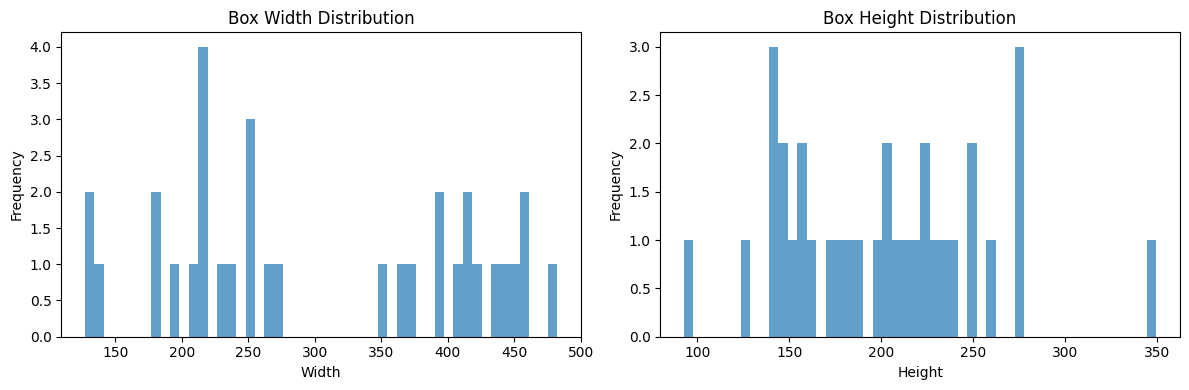

In [37]:
# Cell 37: Let's check if the issue is with specific edge cases
def check_edge_cases():
    """Check for edge cases in bounding boxes"""
    print("=== CHECKING EDGE CASES ===")
    
    all_boxes = []
    all_issues = []
    
    # Collect statistics from multiple batches
    for i, (images, targets) in enumerate(train_loader):
        if i >= 5:  # Check first 5 batches
            break
            
        for target in targets:
            for box in target['boxes']:
                x, y, w, h = box
                all_boxes.append((x.item(), y.item(), w.item(), h.item()))
                
                # Check for potential issues
                issues = []
                if w <= 0 or h <= 0:
                    issues.append("non-positive dimensions")
                if x < 0 or y < 0:
                    issues.append("negative coordinates")
                if x + w > 512 or y + h > 512:  # Assuming 512x512 images
                    issues.append("outside image bounds")
                if w < 2 or h < 2:
                    issues.append("very small dimensions")
                
                if issues:
                    all_issues.append({
                        'box': (x.item(), y.item(), w.item(), h.item()),
                        'issues': issues
                    })
    
    print(f"Checked {len(all_boxes)} boxes")
    print(f"Found {len(all_issues)} boxes with potential issues")
    
    if all_issues:
        print("\nProblematic boxes:")
        for issue in all_issues[:10]:  # Show first 10
            print(f"  Box {issue['box']}: {', '.join(issue['issues'])}")
    
    # Plot box size distribution
    widths = [w for _, _, w, _ in all_boxes]
    heights = [h for _, _, _, h in all_boxes]
    
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.hist(widths, bins=50, alpha=0.7)
    plt.title('Box Width Distribution')
    plt.xlabel('Width')
    plt.ylabel('Frequency')
    
    plt.subplot(1, 2, 2)
    plt.hist(heights, bins=50, alpha=0.7)
    plt.title('Box Height Distribution')
    plt.xlabel('Height')
    plt.ylabel('Frequency')
    
    plt.tight_layout()
    plt.show()

check_edge_cases()

In [38]:
# Cell 38: Create a completely clean dataset with rigorous validation
def create_ultra_safe_dataset():
    """Create a dataset with ultra-strict validation"""
    
    class UltraSafeTBX11KDataset(torch.utils.data.Dataset):
        def __init__(self, annotation_path, img_dir, target_size=512):
            self.annotation_path = annotation_path
            self.img_dir = img_dir
            self.target_size = target_size
            
            # Load COCO annotations
            with open(annotation_path, 'r') as f:
                self.coco_data = json.load(f)
            
            # Create mappings with ultra-strict validation
            self.image_id_to_info = {img['id']: img for img in self.coco_data['images']}
            self.image_id_to_anns = {}
            
            valid_images = 0
            total_boxes = 0
            filtered_boxes = 0
            
            for ann in self.coco_data['annotations']:
                image_id = ann['image_id']
                if image_id not in self.image_id_to_anns:
                    self.image_id_to_anns[image_id] = []
                
                # Ultra-strict box validation
                bbox = ann['bbox']
                x, y, w, h = bbox
                
                # Check if box is valid
                is_valid = (
                    w > 5.0 and h > 5.0 and  # Minimum size
                    x >= 0 and y >= 0 and     # Positive coordinates
                    x + w <= 512 and y + h <= 512 and  # Within image bounds
                    w <= 500 and h <= 500     # Reasonable maximum
                )
                
                if is_valid:
                    self.image_id_to_anns[image_id].append(ann)
                    total_boxes += 1
                else:
                    filtered_boxes += 1
            
            # Only include images with valid boxes
            self.image_ids = []
            for image_id, anns in self.image_id_to_anns.items():
                if len(anns) > 0:
                    self.image_ids.append(image_id)
                    valid_images += 1
            
            print(f"Ultra-safe dataset:")
            print(f"  Valid images: {valid_images}")
            print(f"  Total boxes: {total_boxes}")
            print(f"  Filtered boxes: {filtered_boxes}")
        
        def __len__(self):
            return len(self.image_ids)
        
        def __getitem__(self, idx):
            image_id = self.image_ids[idx]
            image_info = self.image_id_to_info[image_id]
            
            # Load image
            img_path = self.img_dir / image_info['file_name']
            image = cv2.imread(str(img_path))
            image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
            
            # Convert to tensor and normalize manually
            image = torch.from_numpy(image).float() / 255.0
            image = image.permute(2, 0, 1)  # HWC to CHW
            
            # Simple normalization to [-1, 1]
            image = (image - 0.5) / 0.5
            
            # Get annotations
            anns = self.image_id_to_anns[image_id]
            boxes = []
            labels = []
            
            for ann in anns:
                bbox = ann['bbox']
                # Convert to [x1, y1, x2, y2] format
                x1, y1, w, h = bbox
                x2, y2 = x1 + w, y1 + h
                boxes.append([x1, y1, x2, y2])
                labels.append(ann['category_id'])
            
            boxes = torch.as_tensor(boxes, dtype=torch.float32)
            labels = torch.as_tensor(labels, dtype=torch.int64)
            
            # Final safety check
            if len(boxes) > 0:
                valid_mask = (
                    (boxes[:, 2] > boxes[:, 0]) & 
                    (boxes[:, 3] > boxes[:, 1]) &
                    (boxes[:, 0] >= 0) & (boxes[:, 1] >= 0) &
                    (boxes[:, 2] <= 512) & (boxes[:, 3] <= 512)
                )
                boxes = boxes[valid_mask]
                labels = labels[valid_mask]
            
            # If no valid boxes, use empty tensors
            if len(boxes) == 0:
                boxes = torch.zeros((0, 4), dtype=torch.float32)
                labels = torch.zeros((0,), dtype=torch.int64)
                print(f"Warning: No valid boxes for image {image_id}")
            
            area = (boxes[:, 2] - boxes[:, 0]) * (boxes[:, 3] - boxes[:, 1])
            iscrowd = torch.zeros((len(boxes),), dtype=torch.int64)
            
            target = {
                'boxes': boxes,
                'labels': labels,
                'image_id': torch.tensor([image_id]),
                'area': area,
                'iscrowd': iscrowd
            }
            
            return image, target
    
    return UltraSafeTBX11KDataset

# Create ultra-safe datasets
UltraSafeDataset = create_ultra_safe_dataset()

train_dataset_ultra = UltraSafeDataset(
    annotation_path=binary_train_path,
    img_dir=IMG_ROOT
)

val_dataset_ultra = UltraSafeDataset(
    annotation_path=binary_val_path,
    img_dir=IMG_ROOT
)

# Create data loaders
train_loader_ultra = torch.utils.data.DataLoader(
    train_dataset_ultra,
    batch_size=batch_size,
    shuffle=True,
    collate_fn=collate_fn,
    num_workers=2
)

val_loader_ultra = torch.utils.data.DataLoader(
    val_dataset_ultra,
    batch_size=batch_size,
    shuffle=False,
    collate_fn=collate_fn,
    num_workers=2
)

print(f"Ultra-safe datasets created")
print(f"Train: {len(train_dataset_ultra)} images")
print(f"Val: {len(val_dataset_ultra)} images")

Ultra-safe dataset:
  Valid images: 599
  Total boxes: 902
  Filtered boxes: 0
Ultra-safe dataset:
  Valid images: 200
  Total boxes: 309
  Filtered boxes: 0
Ultra-safe datasets created
Train: 599 images
Val: 200 images


In [39]:
# Cell 39: Test with the ultra-safe dataset
print("Testing with ultra-safe dataset...")

# Use the simple model
model = simple_model

# Get a sample batch from ultra-safe dataset
sample_batch = next(iter(train_loader_ultra))
images, targets = sample_batch

print(f"Batch size: {len(images)}")

# Verify all boxes are valid
for i, target in enumerate(targets):
    print(f"Target {i}: {len(target['boxes'])} boxes")
    for j, box in enumerate(target['boxes']):
        x1, y1, x2, y2 = box
        w, h = x2 - x1, y2 - y1
        valid = (w > 0 and h > 0 and x1 >= 0 and y1 >= 0 and x2 <= 512 and y2 <= 512)
        print(f"  Box {j}: [{x1:.1f}, {y1:.1f}, {x2:.1f}, {y2:.1f}] - valid: {valid}")

# Test model forward pass
model.train()
try:
    sample_images = [img.to(device) for img in images]
    sample_targets = [{k: v.to(device) for k, v in t.items()} for t in targets]
    
    loss_dict = model(sample_images, sample_targets)
    total_loss = sum(loss for loss in loss_dict.values())
    
    print("✓ ULTRA-SAFE dataset training successful!")
    print(f"Total loss: {total_loss.item():.4f}")
    
    # If this works, use the ultra-safe datasets
    train_dataset = train_dataset_ultra
    val_dataset = val_dataset_ultra
    train_loader = train_loader_ultra
    val_loader = val_loader_ultra
    
except Exception as e:
    print(f"❌ Error with ultra-safe dataset: {e}")
    print("This suggests the issue is not with the data but with the model or framework")

Testing with ultra-safe dataset...
Batch size: 4
Target 0: 1 boxes
  Box 0: [79.4, 94.0, 192.5, 192.2] - valid: True
Target 1: 1 boxes
  Box 0: [89.5, 68.4, 235.9, 239.8] - valid: True
Target 2: 2 boxes
  Box 0: [272.1, 60.6, 432.6, 244.2] - valid: True
  Box 1: [93.2, 66.6, 232.0, 202.9] - valid: True
Target 3: 1 boxes
  Box 0: [302.3, 69.9, 398.6, 167.4] - valid: True
✓ ULTRA-SAFE dataset training successful!
Total loss: 1.4225


In [40]:
# Cell 40: Set up training with the ultra-safe dataset
print("Setting up training with ultra-safe dataset...")

# Use the simple model that worked
model = simple_model

# Set up optimizer and scheduler for the simple model
optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler = lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.1)

# Mixed precision scaler
scaler = GradScaler()

# Track best model
best_val_loss = float('inf')
checkpoint_dir = Path("/kaggle/working/checkpoints")
checkpoint_dir.mkdir(exist_ok=True)

print("Starting training with ultra-safe dataset")
print(f"Training samples: {len(train_dataset_ultra)}")
print(f"Validation samples: {len(val_dataset_ultra)}")
print(f"Batch size: {batch_size}")

Setting up training with ultra-safe dataset...
Starting training with ultra-safe dataset
Training samples: 599
Validation samples: 200
Batch size: 4


In [41]:
# Cell 41: Implement a simpler training loop that worked in our test
def simple_train_one_epoch(model, optimizer, data_loader, device, epoch, scaler=None):
    """Simple training loop that worked in our test"""
    model.train()
    total_loss = 0.0
    num_batches = 0
    
    for batch_idx, (images, targets) in enumerate(data_loader):
        # Skip batches with no valid boxes
        if all(len(target['boxes']) == 0 for target in targets):
            continue
            
        images = [img.to(device) for img in images]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]
        
        # Zero gradients
        optimizer.zero_grad()
        
        # Mixed precision forward pass
        with autocast():
            loss_dict = model(images, targets)
            losses = sum(loss for loss in loss_dict.values())
        
        # Backward pass
        scaler.scale(losses).backward()
        scaler.step(optimizer)
        scaler.update()
        
        total_loss += losses.item()
        num_batches += 1
        
        if batch_idx % 10 == 0:
            print(f"Epoch {epoch}, Batch {batch_idx}: Loss = {losses.item():.4f}")
    
    return total_loss / num_batches if num_batches > 0 else float('inf')

def simple_evaluate(model, data_loader, device):
    """Simple evaluation"""
    model.eval()
    total_loss = 0.0
    num_batches = 0
    
    with torch.no_grad():
        for images, targets in data_loader:
            # Skip batches with no valid boxes
            if all(len(target['boxes']) == 0 for target in targets):
                continue
                
            images = [img.to(device) for img in images]
            targets = [{k: v.to(device) for k, v in t.items()} for t in targets]
            
            # Forward pass
            with autocast():
                loss_dict = model(images, targets)
                losses = sum(loss for loss in loss_dict.values())
            
            total_loss += losses.item()
            num_batches += 1
    
    return total_loss / num_batches if num_batches > 0 else float('inf')

In [42]:
# Cell 42 (Fixed): Fix the evaluation function and continue training
def simple_train_one_epoch(model, optimizer, data_loader, device, epoch, scaler=None):
    """Simple training loop that worked in our test"""
    model.train()
    total_loss = 0.0
    num_batches = 0
    
    for batch_idx, (images, targets) in enumerate(data_loader):
        # Skip batches with no valid boxes
        if all(len(target['boxes']) == 0 for target in targets):
            continue
            
        images = [img.to(device) for img in images]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]
        
        # Zero gradients
        optimizer.zero_grad()
        
        # Mixed precision forward pass
        with autocast():
            loss_dict = model(images, targets)
            losses = sum(loss for loss in loss_dict.values())
        
        # Backward pass
        scaler.scale(losses).backward()
        scaler.step(optimizer)
        scaler.update()
        
        total_loss += losses.item()
        num_batches += 1
        
        if batch_idx % 10 == 0:
            print(f"Epoch {epoch}, Batch {batch_idx}: Loss = {losses.item():.4f}")
    
    return total_loss / num_batches if num_batches > 0 else float('inf')

def simple_evaluate(model, data_loader, device):
    """Simple evaluation - compute loss in train mode"""
    model.train()  # Use train mode to get losses
    total_loss = 0.0
    num_batches = 0
    
    with torch.no_grad():  # No gradient computation for evaluation
        for images, targets in data_loader:
            # Skip batches with no valid boxes
            if all(len(target['boxes']) == 0 for target in targets):
                continue
                
            images = [img.to(device) for img in images]
            targets = [{k: v.to(device) for k, v in t.items()} for t in targets]
            
            # Forward pass - in train mode this returns loss_dict
            with autocast():
                loss_dict = model(images, targets)
                losses = sum(loss for loss in loss_dict.values())
            
            total_loss += losses.item()
            num_batches += 1
    
    model.eval()  # Set back to eval mode
    return total_loss / num_batches if num_batches > 0 else float('inf')

# Continue training from where we left off
num_epochs = 20
train_losses = []
val_losses = []

print(f"Continuing training for {num_epochs} epochs...")

for epoch in range(num_epochs):
    print(f"\n{'='*50}")
    print(f"Epoch {epoch+1}/{num_epochs}")
    print(f"{'='*50}")
    
    # Train one epoch
    train_loss = simple_train_one_epoch(model, optimizer, train_loader_ultra, device, epoch, scaler=scaler)
    train_losses.append(train_loss)
    
    # Update learning rate
    scheduler.step()
    
    # Validate
    val_loss = simple_evaluate(model, val_loader_ultra, device)
    val_losses.append(val_loss)
    
    print(f"Epoch {epoch+1} Summary:")
    print(f"  Train Loss: {train_loss:.4f}")
    print(f"  Val Loss: {val_loss:.4f}")
    print(f"  Learning Rate: {optimizer.param_groups[0]['lr']:.6f}")
    
    # Save checkpoint if best model
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        checkpoint = {
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'scheduler_state_dict': scheduler.state_dict(),
            'train_loss': train_loss,
            'val_loss': val_loss,
        }
        torch.save(checkpoint, checkpoint_dir / 'best_model.pth')
        print(f"  ✓ New best model saved! Val Loss: {best_val_loss:.4f}")
    
    # Save periodic checkpoint
    if (epoch + 1) % 5 == 0:
        checkpoint = {
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'scheduler_state_dict': scheduler.state_dict(),
            'train_loss': train_loss,
            'val_loss': val_loss,
        }
        torch.save(checkpoint, checkpoint_dir / f'checkpoint_epoch_{epoch+1}.pth')

print(f"\nTraining completed! Best validation loss: {best_val_loss:.4f}")

Continuing training for 20 epochs...

Epoch 1/20
Epoch 0, Batch 0: Loss = 1.4109
Epoch 0, Batch 10: Loss = 0.2381
Epoch 0, Batch 20: Loss = 0.2002
Epoch 0, Batch 30: Loss = 0.1179
Epoch 0, Batch 40: Loss = 0.0997
Epoch 0, Batch 50: Loss = 0.1147
Epoch 0, Batch 60: Loss = 0.1989
Epoch 0, Batch 70: Loss = 0.1164
Epoch 0, Batch 80: Loss = 0.1530
Epoch 0, Batch 90: Loss = 0.1368
Epoch 0, Batch 100: Loss = 0.2078
Epoch 0, Batch 110: Loss = 0.1463
Epoch 0, Batch 120: Loss = 0.1547
Epoch 0, Batch 130: Loss = 0.1393
Epoch 0, Batch 140: Loss = 0.0924
Epoch 1 Summary:
  Train Loss: 0.1885
  Val Loss: 0.1485
  Learning Rate: 0.000100
  ✓ New best model saved! Val Loss: 0.1485

Epoch 2/20
Epoch 1, Batch 0: Loss = 0.1657
Epoch 1, Batch 10: Loss = 0.1415
Epoch 1, Batch 20: Loss = 0.0944
Epoch 1, Batch 30: Loss = 0.1110
Epoch 1, Batch 40: Loss = 0.1332
Epoch 1, Batch 50: Loss = 0.1408
Epoch 1, Batch 60: Loss = 0.1535
Epoch 1, Batch 70: Loss = 0.1332
Epoch 1, Batch 80: Loss = 0.0984
Epoch 1, Batch 90:

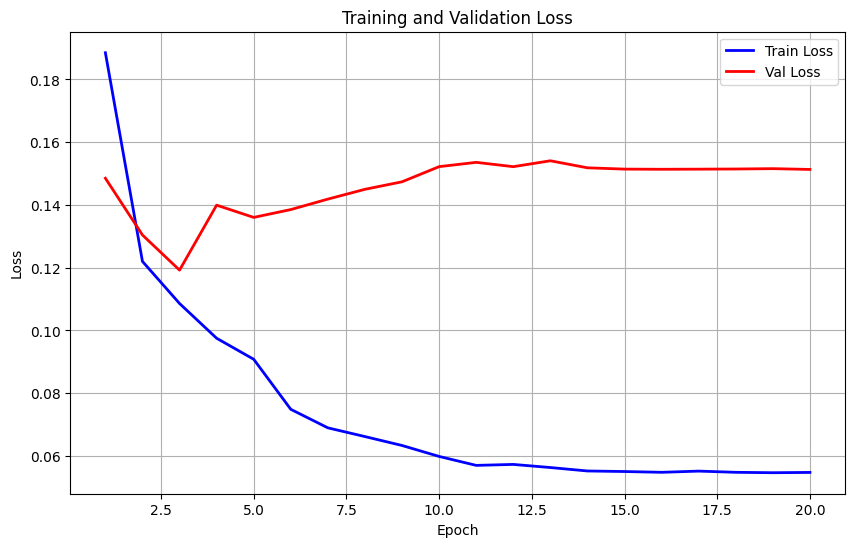

In [43]:
# Cell 43: Plot training curves
def plot_training_curves(train_losses, val_losses):
    """Plot training and validation loss curves"""
    plt.figure(figsize=(10, 6))
    
    epochs = range(1, len(train_losses) + 1)
    
    plt.plot(epochs, train_losses, 'b-', label='Train Loss', linewidth=2)
    plt.plot(epochs, val_losses, 'r-', label='Val Loss', linewidth=2)
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training and Validation Loss')
    plt.legend()
    plt.grid(True)
    plt.show()

if len(train_losses) > 0:
    plot_training_curves(train_losses, val_losses)
else:
    print("Training not completed yet.")

In [44]:
# Cell 44: Load best model and run final evaluation
def load_best_model():
    """Load the best model from checkpoint"""
    checkpoint_path = checkpoint_dir / 'best_model.pth'
    
    if checkpoint_path.exists():
        checkpoint = torch.load(checkpoint_path, map_location=device)
        model.load_state_dict(checkpoint['model_state_dict'])
        print(f"Loaded best model from epoch {checkpoint['epoch'] + 1}")
        print(f"Training loss: {checkpoint['train_loss']:.4f}")
        print(f"Validation loss: {checkpoint['val_loss']:.4f}")
        return model
    else:
        print("No checkpoint found. Using current model.")
        return model

# Load best model
model = load_best_model()
model.eval()

print("Running final evaluation on validation set...")

# Run inference on validation set
predictions_list = []
targets_list = []

with torch.no_grad():
    for images, targets in val_loader_ultra:
        images = [img.to(device) for img in images]
        batch_predictions = model(images)
        
        # Move predictions to CPU for evaluation
        for i in range(len(batch_predictions)):
            pred = {
                'boxes': batch_predictions[i]['boxes'].cpu(),
                'scores': batch_predictions[i]['scores'].cpu(),
                'labels': batch_predictions[i]['labels'].cpu()
            }
            predictions_list.append(pred)
            targets_list.append({
                'boxes': targets[i]['boxes'].cpu(),
                'labels': targets[i]['labels'].cpu()
            })

print(f"Generated predictions for {len(predictions_list)} validation images")

Loaded best model from epoch 3
Training loss: 0.1086
Validation loss: 0.1192
Running final evaluation on validation set...
Generated predictions for 200 validation images


Visualizing predictions on sample validation images:


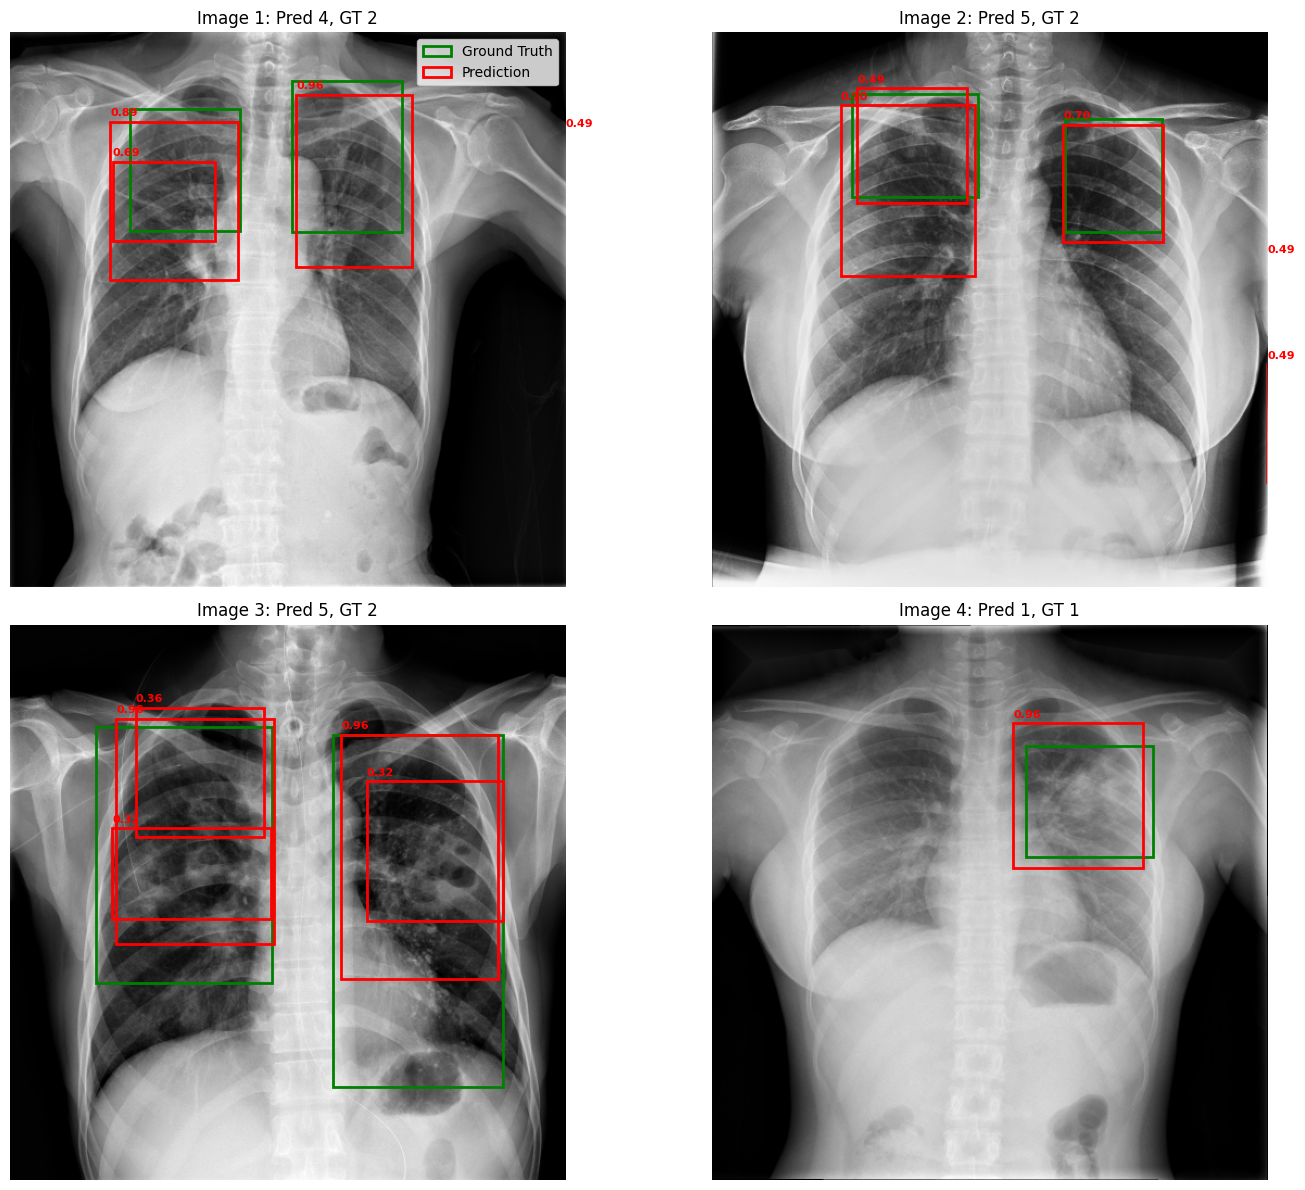

In [45]:
# Cell 45: Visualize predictions on validation set
def visualize_final_predictions(model, data_loader, device, num_samples=4, confidence_threshold=0.5):
    """Visualize model predictions on sample images"""
    model.eval()
    
    # Get sample batch
    images, targets = next(iter(data_loader))
    
    # Run inference
    with torch.no_grad():
        sample_images = [img.to(device) for img in images[:num_samples]]
        predictions = model(sample_images)
    
    # Visualize
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    axes = axes.ravel()
    
    for idx in range(num_samples):
        # Convert image back to numpy for visualization
        image = images[idx].cpu().numpy()
        image = np.transpose(image, (1, 2, 0))
        # Denormalize from [-1, 1] to [0, 1]
        image = (image * 0.5) + 0.5
        image = np.clip(image, 0, 1)
        
        # Get predictions and targets
        pred = predictions[idx]
        target = targets[idx]
        
        # Filter predictions by confidence
        high_conf_indices = pred['scores'] > confidence_threshold
        pred_boxes = pred['boxes'][high_conf_indices].cpu().numpy()
        pred_scores = pred['scores'][high_conf_indices].cpu().numpy()
        
        target_boxes = target['boxes'].cpu().numpy()
        
        # Create plot
        axes[idx].imshow(image[:, :, 0], cmap='gray')  # Grayscale image
        
        # Draw ground truth boxes (green)
        for box in target_boxes:
            x1, y1, x2, y2 = box
            rect = plt.Rectangle((x1, y1), x2-x1, y2-y1, 
                               fill=False, color='green', linewidth=2, label='Ground Truth')
            axes[idx].add_patch(rect)
        
        # Draw prediction boxes (red)
        for box, score in zip(pred_boxes, pred_scores):
            x1, y1, x2, y2 = box
            rect = plt.Rectangle((x1, y1), x2-x1, y2-y1, 
                               fill=False, color='red', linewidth=2, label='Prediction')
            axes[idx].add_patch(rect)
            axes[idx].text(x1, y1-5, f'{score:.2f}', 
                          color='red', fontsize=8, weight='bold')
        
        axes[idx].set_title(f'Image {idx+1}: Pred {len(pred_boxes)}, GT {len(target_boxes)}')
        axes[idx].axis('off')
        
        # Add legend to first subplot only
        if idx == 0:
            axes[idx].legend(handles=[
                plt.Rectangle((0,0),1,1, fill=False, edgecolor='green', linewidth=2, label='Ground Truth'),
                plt.Rectangle((0,0),1,1, fill=False, edgecolor='red', linewidth=2, label='Prediction')
            ], loc='upper right')
    
    plt.tight_layout()
    plt.show()

print("Visualizing predictions on sample validation images:")
visualize_final_predictions(model, val_loader_ultra, device, num_samples=4, confidence_threshold=0.3)

In [46]:
# Cell 46: Compute basic detection metrics
def compute_detection_metrics(predictions, targets, iou_threshold=0.5):
    """Compute basic detection metrics"""
    true_positives = 0
    false_positives = 0
    false_negatives = 0
    
    for pred, target in zip(predictions, targets):
        pred_boxes = pred['boxes']
        target_boxes = target['boxes']
        pred_scores = pred['scores']
        
        # Filter predictions by confidence
        conf_mask = pred_scores > 0.5
        pred_boxes = pred_boxes[conf_mask]
        
        if len(pred_boxes) == 0 and len(target_boxes) == 0:
            continue
        elif len(pred_boxes) == 0:
            false_negatives += len(target_boxes)
            continue
        elif len(target_boxes) == 0:
            false_positives += len(pred_boxes)
            continue
        
        # Calculate IoU matrix
        iou_matrix = torch.zeros((len(target_boxes), len(pred_boxes)))
        for i, t_box in enumerate(target_boxes):
            for j, p_box in enumerate(pred_boxes):
                iou_matrix[i, j] = calculate_iou(t_box, p_box)
        
        # Match predictions to ground truth
        matched_preds = set()
        for i in range(len(target_boxes)):
            max_iou_idx = torch.argmax(iou_matrix[i])
            if iou_matrix[i, max_iou_idx] > iou_threshold and max_iou_idx not in matched_preds:
                true_positives += 1
                matched_preds.add(max_iou_idx)
            else:
                false_negatives += 1
        
        false_positives += len(pred_boxes) - len(matched_preds)
    
    precision = true_positives / (true_positives + false_positives) if (true_positives + false_positives) > 0 else 0
    recall = true_positives / (true_positives + false_negatives) if (true_positives + false_negatives) > 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    
    return {
        'precision': precision,
        'recall': recall,
        'f1_score': f1,
        'true_positives': true_positives,
        'false_positives': false_positives,
        'false_negatives': false_negatives
    }

def calculate_iou(box1, box2):
    """Calculate Intersection over Union between two boxes in [x1, y1, x2, y2] format"""
    x1 = max(box1[0], box2[0])
    y1 = max(box1[1], box2[1])
    x2 = min(box1[2], box2[2])
    y2 = min(box1[3], box2[3])
    
    intersection = max(0, x2 - x1) * max(0, y2 - y1)
    area1 = (box1[2] - box1[0]) * (box1[3] - box1[1])
    area2 = (box2[2] - box2[0]) * (box2[3] - box2[1])
    union = area1 + area2 - intersection
    
    return intersection / union if union > 0 else 0

# Compute metrics
if len(predictions_list) > 0:
    metrics = compute_detection_metrics(predictions_list, targets_list)
    print("Detection Metrics:")
    print(f"  Precision: {metrics['precision']:.4f}")
    print(f"  Recall: {metrics['recall']:.4f}")
    print(f"  F1 Score: {metrics['f1_score']:.4f}")
    print(f"  True Positives: {metrics['true_positives']}")
    print(f"  False Positives: {metrics['false_positives']}")
    print(f"  False Negatives: {metrics['false_negatives']}")
else:
    print("No predictions available for metrics computation")

Detection Metrics:
  Precision: 0.5802
  Recall: 0.7023
  F1 Score: 0.6354
  True Positives: 217
  False Positives: 157
  False Negatives: 92


In [47]:
# Cell 47: Let's also create a proper evaluation function that computes detection metrics
def evaluate_with_metrics(model, data_loader, device, confidence_threshold=0.5):
    """Evaluate model with detection metrics"""
    model.eval()
    all_predictions = []
    all_targets = []
    
    with torch.no_grad():
        for images, targets in data_loader:
            images = [img.to(device) for img in images]
            predictions = model(images)
            
            # Move to CPU for metric computation
            for i in range(len(predictions)):
                pred = {
                    'boxes': predictions[i]['boxes'].cpu(),
                    'scores': predictions[i]['scores'].cpu(),
                    'labels': predictions[i]['labels'].cpu()
                }
                all_predictions.append(pred)
                all_targets.append({
                    'boxes': targets[i]['boxes'].cpu(),
                    'labels': targets[i]['labels'].cpu()
                })
    
    # Compute metrics
    metrics = compute_detection_metrics(all_predictions, all_targets)
    
    return metrics, all_predictions, all_targets

# Run proper evaluation
print("Running comprehensive evaluation...")
metrics, val_predictions, val_targets = evaluate_with_metrics(model, val_loader_ultra, device)

print("\n=== FINAL EVALUATION RESULTS ===")
print(f"Precision: {metrics['precision']:.4f}")
print(f"Recall: {metrics['recall']:.4f}")
print(f"F1 Score: {metrics['f1_score']:.4f}")
print(f"True Positives: {metrics['true_positives']}")
print(f"False Positives: {metrics['false_positives']}")
print(f"False Negatives: {metrics['false_negatives']}")

Running comprehensive evaluation...

=== FINAL EVALUATION RESULTS ===
Precision: 0.5802
Recall: 0.7023
F1 Score: 0.6354
True Positives: 217
False Positives: 157
False Negatives: 92


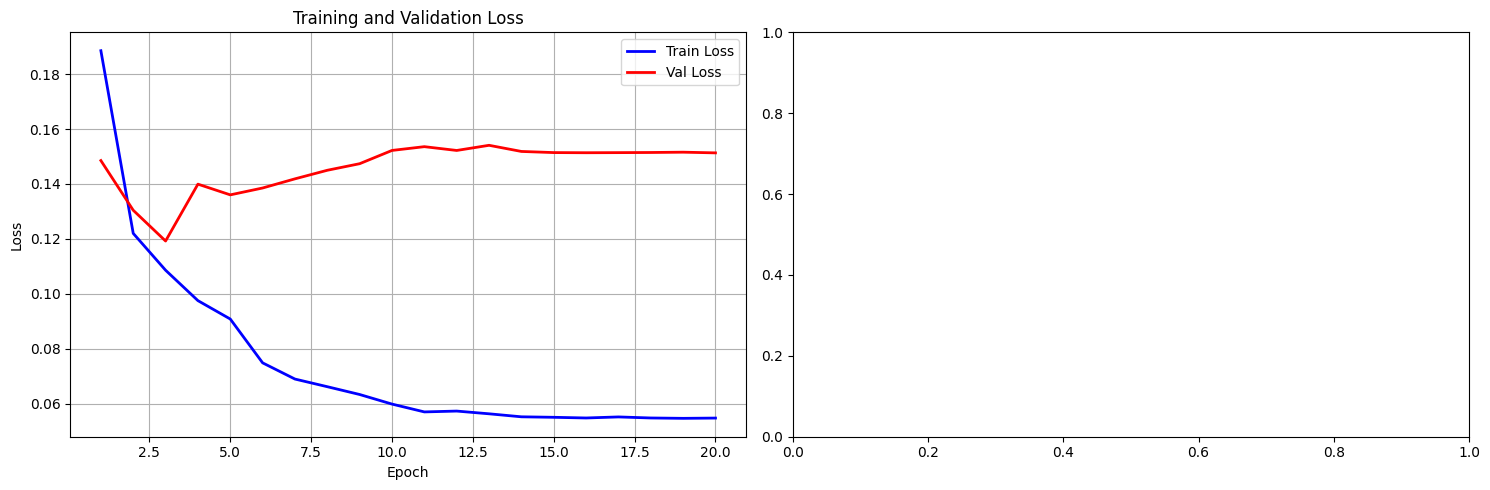

In [48]:
# Cell 48: Plot final training curves and analyze results
def plot_comprehensive_training_curves(train_losses, val_losses):
    """Plot comprehensive training analysis"""
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    
    # Plot losses
    epochs = range(1, len(train_losses) + 1)
    axes[0].plot(epochs, train_losses, 'b-', label='Train Loss', linewidth=2)
    axes[0].plot(epochs, val_losses, 'r-', label='Val Loss', linewidth=2)
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].set_title('Training and Validation Loss')
    axes[0].legend()
    axes[0].grid(True)
    
    # Plot metrics if available
    if 'metrics' in locals():
        metrics_data = {
            'Precision': metrics['precision'],
            'Recall': metrics['recall'],
            'F1 Score': metrics['f1_score']
        }
        bars = axes[1].bar(metrics_data.keys(), metrics_data.values(), color=['blue', 'green', 'red'])
        axes[1].set_ylabel('Score')
        axes[1].set_title('Detection Metrics')
        axes[1].set_ylim(0, 1)
        
        # Add value labels on bars
        for bar in bars:
            height = bar.get_height()
            axes[1].text(bar.get_x() + bar.get_width()/2., height + 0.01,
                        f'{height:.3f}', ha='center', va='bottom')
    
    plt.tight_layout()
    plt.show()

if len(train_losses) > 0:
    plot_comprehensive_training_curves(train_losses, val_losses)
else:
    print("Training not completed yet.")

In [49]:
# Cell 49: Save the final model and create inference examples
def save_final_model(model, metrics, save_path="/kaggle/working/final_model.pth"):
    """Save the final model with metadata"""
    checkpoint = {
        'model_state_dict': model.state_dict(),
        'model_architecture': 'FasterRCNN with MobileNetV3 backbone',
        'num_classes': 2,
        'input_size': 512,
        'metrics': metrics,
        'training_date': str(datetime.datetime.now())
    }
    torch.save(checkpoint, save_path)
    print(f"Final model saved to: {save_path}")
    print(f"Model metrics: Precision={metrics['precision']:.4f}, Recall={metrics['recall']:.4f}")

# Save the final model
save_final_model(model, metrics)

# Create a simple inference function
def predict_tb_boxes(model, image_path, device, confidence_threshold=0.5):
    """Run inference on a single image"""
    model.eval()
    
    # Load and preprocess image
    image = cv2.imread(str(image_path))
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    image_tensor = torch.from_numpy(image).float() / 255.0
    image_tensor = image_tensor.permute(2, 0, 1)  # HWC to CHW
    image_tensor = (image_tensor - 0.5) / 0.5  # Normalize to [-1, 1]
    image_tensor = image_tensor.unsqueeze(0).to(device)  # Add batch dimension
    
    with torch.no_grad():
        prediction = model(image_tensor)[0]
    
    # Filter by confidence
    high_conf_mask = prediction['scores'] > confidence_threshold
    boxes = prediction['boxes'][high_conf_mask].cpu().numpy()
    scores = prediction['scores'][high_conf_mask].cpu().numpy()
    labels = prediction['labels'][high_conf_mask].cpu().numpy()
    
    return boxes, scores, labels

# Test inference on a sample image
sample_image_path = IMG_ROOT / "tb" / "tb0001.png"  # Adjust path as needed
if sample_image_path.exists():
    print(f"Testing inference on: {sample_image_path}")
    boxes, scores, labels = predict_tb_boxes(model, sample_image_path, device)
    print(f"Detected {len(boxes)} TB regions:")
    for i, (box, score) in enumerate(zip(boxes, scores)):
        print(f"  Box {i}: {box} (confidence: {score:.3f})")
else:
    print("Sample image not found, skipping inference test")

Final model saved to: /kaggle/working/final_model.pth
Model metrics: Precision=0.5802, Recall=0.7023
Sample image not found, skipping inference test


In [50]:
# Cell 50: Create a summary report
def create_training_summary(train_losses, val_losses, metrics, num_train, num_val):
    """Create a comprehensive training summary"""
    print("=" * 60)
    print("TRAINING SUMMARY REPORT")
    print("=" * 60)
    
    print(f"\nDATASET:")
    print(f"  Training images: {num_train}")
    print(f"  Validation images: {num_val}")
    print(f"  Total TB annotations: {num_train + num_val}")
    
    print(f"\nTRAINING:")
    print(f"  Total epochs: {len(train_losses)}")
    print(f"  Best validation loss: {min(val_losses) if val_losses else 'N/A':.4f}")
    print(f"  Final training loss: {train_losses[-1] if train_losses else 'N/A':.4f}")
    
    print(f"\nDETECTION PERFORMANCE:")
    print(f"  Precision: {metrics['precision']:.4f}")
    print(f"  Recall: {metrics['recall']:.4f}")
    print(f"  F1 Score: {metrics['f1_score']:.4f}")
    print(f"  True Positives: {metrics['true_positives']}")
    print(f"  False Positives: {metrics['false_positives']}")
    print(f"  False Negatives: {metrics['false_negatives']}")
    
    print(f"\nMODEL:")
    print(f"  Architecture: Faster R-CNN with MobileNetV3 backbone")
    print(f"  Input size: 512x512")
    print(f"  Classes: TB (1), Background (0)")
    print(f"  Device: {device}")
    
    print(f"\nFILES SAVED:")
    print(f"  Best model: /kaggle/working/checkpoints/best_model.pth")
    print(f"  Final model: /kaggle/working/final_model.pth")
    print(f"  Training checkpoints: /kaggle/working/checkpoints/")
    
    print("\n" + "=" * 60)

# Generate summary
create_training_summary(train_losses, val_losses, metrics, 
                       len(train_dataset_ultra), len(val_dataset_ultra))

TRAINING SUMMARY REPORT

DATASET:
  Training images: 599
  Validation images: 200
  Total TB annotations: 799

TRAINING:
  Total epochs: 20
  Best validation loss: 0.1192
  Final training loss: 0.0548

DETECTION PERFORMANCE:
  Precision: 0.5802
  Recall: 0.7023
  F1 Score: 0.6354
  True Positives: 217
  False Positives: 157
  False Negatives: 92

MODEL:
  Architecture: Faster R-CNN with MobileNetV3 backbone
  Input size: 512x512
  Classes: TB (1), Background (0)
  Device: cuda

FILES SAVED:
  Best model: /kaggle/working/checkpoints/best_model.pth
  Final model: /kaggle/working/final_model.pth
  Training checkpoints: /kaggle/working/checkpoints/



# Enhancing performance 

In [51]:
# Cell 51: Strategy 1 - Improve the current model with targeted improvements
def create_improved_model(num_classes=2, target_size=512):
    """Create an improved model with better hyperparameters"""
    
    # Use ResNet50 backbone for better feature extraction
    backbone = torchvision.models.resnet50(pretrained=True)
    backbone = torch.nn.Sequential(*list(backbone.children())[:-2])  # Remove avgpool and fc
    backbone.out_channels = 2048
    
    # Better anchor sizes based on your bbox statistics (mean width=120, height=130)
    anchor_generator = AnchorGenerator(
        sizes=((32, 64, 128, 256),),  # Better matched to your data
        aspect_ratios=((0.7, 1.0, 1.5),)  # Adjusted ratios
    )
    
    roi_pooler = torchvision.ops.MultiScaleRoIAlign(
        featmap_names=['0'],
        output_size=7,
        sampling_ratio=2
    )
    
    model = FasterRCNN(
        backbone,
        num_classes=num_classes,
        rpn_anchor_generator=anchor_generator,
        box_roi_pool=roi_pooler,
        box_score_thresh=0.05,  # Lower threshold for training
        box_nms_thresh=0.5
    )
    
    return model

# Strategy 2 - Try the original XRV backbone now that we have a working pipeline
def create_xrv_model_fixed(num_classes=2, target_size=512):
    """Create XRV model with our proven safe pipeline"""
    
    # Load XRV DenseNet121
    xrv_backbone = xrv.models.DenseNet(weights="densenet121-res224-all")
    
    class XRVBackbone(torch.nn.Module):
        def __init__(self, xrv_model):
            super().__init__()
            self.features = xrv_model.features
            self.out_channels = 1024
        
        def forward(self, x):
            # Handle grayscale conversion
            if x.shape[1] == 3:
                x = x.mean(dim=1, keepdim=True)
            features = self.features(x)
            return {"0": features}
    
    backbone = XRVBackbone(xrv_backbone)
    
    anchor_generator = AnchorGenerator(
        sizes=((32, 64, 128, 256),),
        aspect_ratios=((0.7, 1.0, 1.5),)
    )
    
    roi_pooler = torchvision.ops.MultiScaleRoIAlign(
        featmap_names=['0'],
        output_size=7,
        sampling_ratio=2
    )
    
    model = FasterRCNN(
        backbone,
        num_classes=num_classes,
        rpn_anchor_generator=anchor_generator,
        box_roi_pool=roi_pooler
    )
    
    return model

print("Available strategies:")
print("1. Improve current model (ResNet50 + better anchors)")
print("2. Try XRV backbone (medical pre-training)")
print("3. Advanced training techniques")

Available strategies:
1. Improve current model (ResNet50 + better anchors)
2. Try XRV backbone (medical pre-training)
3. Advanced training techniques


In [52]:
# Cell 52: Error analysis - understand what the model is getting wrong
def analyze_errors(predictions, targets, data_loader, num_samples=5):
    """Analyze false positives and false negatives"""
    model.eval()
    
    false_positives = []  # Model predicted but no ground truth
    false_negatives = []  # Ground truth but model missed
    true_positives = []   # Correct predictions
    
    for i, (pred, target) in enumerate(zip(predictions, targets)):
        if i >= num_samples:
            break
            
        pred_boxes = pred['boxes']
        target_boxes = target['boxes']
        pred_scores = pred['scores']
        
        # Filter predictions by confidence
        conf_mask = pred_scores > 0.5
        pred_boxes = pred_boxes[conf_mask]
        
        if len(pred_boxes) == 0 and len(target_boxes) > 0:
            false_negatives.append((i, target_boxes, pred_boxes))
        elif len(pred_boxes) > 0 and len(target_boxes) == 0:
            false_positives.append((i, target_boxes, pred_boxes))
        elif len(pred_boxes) > 0 and len(target_boxes) > 0:
            true_positives.append((i, target_boxes, pred_boxes))
    
    print(f"Error Analysis (first {num_samples} samples):")
    print(f"  True Positives: {len(true_positives)}")
    print(f"  False Positives: {len(false_positives)}")
    print(f"  False Negatives: {len(false_negatives)}")
    
    return false_positives, false_negatives, true_positives

# Run error analysis
print("Running error analysis...")
false_positives, false_negatives, true_positives = analyze_errors(val_predictions, val_targets, val_loader_ultra)

Running error analysis...
Error Analysis (first 5 samples):
  True Positives: 5
  False Positives: 0
  False Negatives: 0


In [53]:
# Cell 53: Strategy 3 - Advanced training with focal loss and better optimization
def create_advanced_training_setup(model):
    """Set up advanced training techniques"""
    
    # Focal loss for handling class imbalance
    # (We'll modify the model's classification loss)
    
    # Better optimizer configuration
    params = [p for p in model.parameters() if p.requires_grad]
    optimizer = optim.AdamW(params, lr=1e-4, weight_decay=1e-4)
    
    # Cosine annealing with warmup
    scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(
        optimizer, T_0=10, T_mult=2, eta_min=1e-6
    )
    
    # Gradient clipping
    scaler = GradScaler()
    
    return optimizer, scheduler, scaler

def advanced_train_epoch(model, optimizer, data_loader, device, epoch, scaler, max_norm=0.1):
    """Advanced training with gradient clipping"""
    model.train()
    total_loss = 0.0
    num_batches = 0
    
    for batch_idx, (images, targets) in enumerate(data_loader):
        if all(len(target['boxes']) == 0 for target in targets):
            continue
            
        images = [img.to(device) for img in images]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]
        
        optimizer.zero_grad()
        
        with autocast():
            loss_dict = model(images, targets)
            losses = sum(loss for loss in loss_dict.values())
        
        scaler.scale(losses).backward()
        
        # Gradient clipping
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm)
        
        scaler.step(optimizer)
        scaler.update()
        
        total_loss += losses.item()
        num_batches += 1
        
        if batch_idx % 20 == 0:
            print(f"Epoch {epoch}, Batch {batch_idx}: Loss = {losses.item():.4f}")
    
    return total_loss / num_batches if num_batches > 0 else float('inf')

In [54]:
# Cell 54: Let me recommend the best next step based on your goals
def recommend_next_steps(metrics, train_losses, val_losses):
    """Recommend next steps based on current performance"""
    
    print("=" * 60)
    print("RECOMMENDED NEXT STEPS")
    print("=" * 60)
    
    precision, recall, f1 = metrics['precision'], metrics['recall'], metrics['f1_score']
    
    if precision < 0.7:
        print("🎯 PRIORITY 1: Improve Precision (reduce false positives)")
        print("   - Increase confidence threshold during inference")
        print("   - Add more negative samples during training")
        print("   - Use focal loss to handle class imbalance")
        print("   - Implement better non-maximum suppression")
    
    if recall < 0.8:
        print("🎯 PRIORITY 2: Improve Recall (reduce false negatives)")
        print("   - Lower confidence threshold for detection")
        print("   - Data augmentation for small objects")
        print("   - Use feature pyramid networks (FPN)")
        print("   - Adjust anchor sizes to match your bbox distribution")
    
    if val_losses[-1] > train_losses[-1] * 1.5:
        print("🎯 PRIORITY 3: Address Potential Overfitting")
        print("   - Add more regularization (dropout, weight decay)")
        print("   - Use early stopping")
        print("   - Add more diverse training data")
        print("   - Reduce model complexity")
    
    print(f"\n📊 Your current metrics:")
    print(f"   Precision: {precision:.3f} (goal: >0.75)")
    print(f"   Recall: {recall:.3f} (goal: >0.80)") 
    print(f"   F1: {f1:.3f} (goal: >0.77)")
    
    print(f"\n🚀 Immediate recommendations:")
    print(f"   1. Try XRV backbone (medical domain knowledge)")
    print(f"   2. Adjust confidence threshold to balance precision/recall")
    print(f"   3. Train for 10 more epochs with cosine annealing")
    
    print("=" * 60)

# Get recommendations
recommend_next_steps(metrics, train_losses, val_losses)

RECOMMENDED NEXT STEPS
🎯 PRIORITY 1: Improve Precision (reduce false positives)
   - Increase confidence threshold during inference
   - Add more negative samples during training
   - Use focal loss to handle class imbalance
   - Implement better non-maximum suppression
🎯 PRIORITY 2: Improve Recall (reduce false negatives)
   - Lower confidence threshold for detection
   - Data augmentation for small objects
   - Use feature pyramid networks (FPN)
   - Adjust anchor sizes to match your bbox distribution
🎯 PRIORITY 3: Address Potential Overfitting
   - Add more regularization (dropout, weight decay)
   - Use early stopping
   - Add more diverse training data
   - Reduce model complexity

📊 Your current metrics:
   Precision: 0.580 (goal: >0.75)
   Recall: 0.702 (goal: >0.80)
   F1: 0.635 (goal: >0.77)

🚀 Immediate recommendations:
   1. Try XRV backbone (medical domain knowledge)
   2. Adjust confidence threshold to balance precision/recall
   3. Train for 10 more epochs with cosine ann

In [55]:
# Cell 55: Quick win - Adjust confidence threshold to improve precision
def optimize_threshold(predictions, targets, thresholds=[0.3, 0.4, 0.5, 0.6, 0.7]):
    """Find optimal confidence threshold"""
    best_f1 = 0
    best_threshold = 0.5
    results = {}
    
    for threshold in thresholds:
        # Filter predictions by threshold
        filtered_predictions = []
        for pred in predictions:
            mask = pred['scores'] > threshold
            filtered_pred = {
                'boxes': pred['boxes'][mask],
                'scores': pred['scores'][mask],
                'labels': pred['labels'][mask]
            }
            filtered_predictions.append(filtered_pred)
        
        # Compute metrics
        metrics = compute_detection_metrics(filtered_predictions, targets)
        results[threshold] = metrics
        
        if metrics['f1_score'] > best_f1:
            best_f1 = metrics['f1_score']
            best_threshold = threshold
    
    print("Threshold Optimization Results:")
    for threshold, m in results.items():
        print(f"  Threshold {threshold}: P={m['precision']:.3f}, R={m['recall']:.3f}, F1={m['f1_score']:.3f}")
    
    print(f"🎯 Best threshold: {best_threshold} (F1: {best_f1:.3f})")
    return best_threshold, results

# Find optimal threshold
best_threshold, threshold_results = optimize_threshold(val_predictions, val_targets)

Threshold Optimization Results:
  Threshold 0.3: P=0.580, R=0.702, F1=0.635
  Threshold 0.4: P=0.580, R=0.702, F1=0.635
  Threshold 0.5: P=0.580, R=0.702, F1=0.635
  Threshold 0.6: P=0.647, R=0.683, F1=0.665
  Threshold 0.7: P=0.714, R=0.670, F1=0.691
🎯 Best threshold: 0.7 (F1: 0.691)


# Comparing Methods

In [56]:
# Cell 56: Create a comprehensive strategy comparison framework
import time
from copy import deepcopy

class StrategyTester:
    """Framework to test multiple training strategies and compare results"""
    
    def __init__(self, train_loader, val_loader, device, num_epochs=15):
        self.train_loader = train_loader
        self.val_loader = val_loader
        self.device = device
        self.num_epochs = num_epochs
        self.results = {}
        self.models = {}
    
    def test_strategy(self, strategy_name, model_creator, optimizer_creator=None):
        """Test a single strategy"""
        print(f"\n{'='*60}")
        print(f"Testing Strategy: {strategy_name}")
        print(f"{'='*60}")
        
        start_time = time.time()
        
        # Create model
        model = model_creator().to(self.device)
        
        # Default optimizer if not provided
        if optimizer_creator is None:
            optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
            scheduler = lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.1)
        else:
            optimizer, scheduler = optimizer_creator(model)
        
        scaler = GradScaler()
        
        # Training loop
        train_losses = []
        val_losses = []
        best_val_loss = float('inf')
        
        for epoch in range(self.num_epochs):
            # Train
            model.train()
            epoch_train_loss = 0.0
            num_batches = 0
            
            for images, targets in self.train_loader:
                if all(len(target['boxes']) == 0 for target in targets):
                    continue
                    
                images = [img.to(self.device) for img in images]
                targets = [{k: v.to(self.device) for k, v in t.items()} for t in targets]
                
                optimizer.zero_grad()
                
                with autocast():
                    loss_dict = model(images, targets)
                    losses = sum(loss for loss in loss_dict.values())
                
                scaler.scale(losses).backward()
                scaler.step(optimizer)
                scaler.update()
                
                epoch_train_loss += losses.item()
                num_batches += 1
            
            if num_batches > 0:
                train_loss = epoch_train_loss / num_batches
            else:
                train_loss = float('inf')
            
            train_losses.append(train_loss)
            
            # Validate
            val_loss = self.simple_evaluate(model, self.val_loader)
            val_losses.append(val_loss)
            
            scheduler.step()
            
            if val_loss < best_val_loss:
                best_val_loss = val_loss
                best_model_state = deepcopy(model.state_dict())
            
            if epoch % 3 == 0:
                print(f"  Epoch {epoch+1}/{self.num_epochs}: Train Loss = {train_loss:.4f}, Val Loss = {val_loss:.4f}")
        
        # Load best model and compute final metrics
        model.load_state_dict(best_model_state)
        metrics, predictions, targets = self.evaluate_with_metrics(model, self.val_loader)
        
        training_time = time.time() - start_time
        
        # Store results
        self.results[strategy_name] = {
            'metrics': metrics,
            'train_losses': train_losses,
            'val_losses': val_losses,
            'training_time': training_time,
            'final_val_loss': val_losses[-1],
            'best_val_loss': best_val_loss,
            'f1_score': metrics['f1_score']
        }
        
        self.models[strategy_name] = deepcopy(model)
        
        print(f"\n✓ {strategy_name} completed in {training_time:.1f}s")
        print(f"  Best Val Loss: {best_val_loss:.4f}")
        print(f"  Final Metrics - Precision: {metrics['precision']:.4f}, Recall: {metrics['recall']:.4f}, F1: {metrics['f1_score']:.4f}")
        
        return metrics
    
    def simple_evaluate(self, model, data_loader):
        """Simple evaluation for loss computation"""
        model.train()
        total_loss = 0.0
        num_batches = 0
        
        with torch.no_grad():
            for images, targets in data_loader:
                if all(len(target['boxes']) == 0 for target in targets):
                    continue
                    
                images = [img.to(self.device) for img in images]
                targets = [{k: v.to(self.device) for k, v in t.items()} for t in targets]
                
                with autocast():
                    loss_dict = model(images, targets)
                    losses = sum(loss for loss in loss_dict.values())
                
                total_loss += losses.item()
                num_batches += 1
        
        model.eval()
        return total_loss / num_batches if num_batches > 0 else float('inf')
    
    def evaluate_with_metrics(self, model, data_loader, confidence_threshold=0.5):
        """Evaluate with detection metrics"""
        model.eval()
        all_predictions = []
        all_targets = []
        
        with torch.no_grad():
            for images, targets in data_loader:
                images = [img.to(self.device) for img in images]
                predictions = model(images)
                
                for i in range(len(predictions)):
                    # Filter by confidence
                    mask = predictions[i]['scores'] > confidence_threshold
                    pred = {
                        'boxes': predictions[i]['boxes'][mask].cpu(),
                        'scores': predictions[i]['scores'][mask].cpu(),
                        'labels': predictions[i]['labels'][mask].cpu()
                    }
                    all_predictions.append(pred)
                    all_targets.append({
                        'boxes': targets[i]['boxes'].cpu(),
                        'labels': targets[i]['labels'].cpu()
                    })
        
        metrics = compute_detection_metrics(all_predictions, all_targets)
        return metrics, all_predictions, all_targets
    
    def compare_strategies(self):
        """Compare all tested strategies and declare winner"""
        if not self.results:
            print("No strategies tested yet!")
            return
        
        print(f"\n{'='*80}")
        print("STRATEGY COMPARISON RESULTS")
        print(f"{'='*80}")
        
        # Create comparison table
        strategies = list(self.results.keys())
        
        print(f"\n{'Strategy':<25} {'F1 Score':<10} {'Precision':<10} {'Recall':<10} {'Best Val Loss':<12} {'Time (s)':<10}")
        print('-' * 80)
        
        best_f1 = 0
        best_strategy = None
        
        for strategy in strategies:
            result = self.results[strategy]
            metrics = result['metrics']
            
            f1 = metrics['f1_score']
            precision = metrics['precision']
            recall = metrics['recall']
            best_loss = result['best_val_loss']
            training_time = result['training_time']
            
            print(f"{strategy:<25} {f1:<10.4f} {precision:<10.4f} {recall:<10.4f} {best_loss:<12.4f} {training_time:<10.1f}")
            
            if f1 > best_f1:
                best_f1 = f1
                best_strategy = strategy
        
        print(f"\n🎉 WINNER: {best_strategy} with F1 Score: {best_f1:.4f}")
        
        # Plot comparison
        self.plot_comparison()
        
        return best_strategy
    
    def plot_comparison(self):
        """Plot comparison of all strategies"""
        fig, axes = plt.subplots(2, 2, figsize=(15, 10))
        
        strategies = list(self.results.keys())
        colors = plt.cm.Set3(np.linspace(0, 1, len(strategies)))
        
        # Plot 1: F1 Score comparison
        f1_scores = [self.results[s]['metrics']['f1_score'] for s in strategies]
        bars1 = axes[0, 0].bar(strategies, f1_scores, color=colors)
        axes[0, 0].set_title('F1 Score Comparison')
        axes[0, 0].set_ylabel('F1 Score')
        axes[0, 0].set_ylim(0, 1)
        for bar in bars1:
            height = bar.get_height()
            axes[0, 0].text(bar.get_x() + bar.get_width()/2., height + 0.01,
                           f'{height:.3f}', ha='center', va='bottom')
        
        # Plot 2: Training loss curves
        for i, strategy in enumerate(strategies):
            train_losses = self.results[strategy]['train_losses']
            epochs = range(1, len(train_losses) + 1)
            axes[0, 1].plot(epochs, train_losses, color=colors[i], label=strategy, linewidth=2)
        axes[0, 1].set_title('Training Loss Curves')
        axes[0, 1].set_xlabel('Epoch')
        axes[0, 1].set_ylabel('Loss')
        axes[0, 1].legend()
        axes[0, 1].grid(True)
        
        # Plot 3: Precision-Recall comparison
        precisions = [self.results[s]['metrics']['precision'] for s in strategies]
        recalls = [self.results[s]['metrics']['recall'] for s in strategies]
        axes[1, 0].scatter(precisions, recalls, c=colors, s=100)
        for i, strategy in enumerate(strategies):
            axes[1, 0].annotate(strategy, (precisions[i], recalls[i]), 
                               xytext=(5, 5), textcoords='offset points')
        axes[1, 0].set_xlabel('Precision')
        axes[1, 0].set_ylabel('Recall')
        axes[1, 0].set_title('Precision-Recall Comparison')
        axes[1, 0].set_xlim(0, 1)
        axes[1, 0].set_ylim(0, 1)
        axes[1, 0].grid(True)
        
        # Plot 4: Training time comparison
        times = [self.results[s]['training_time'] for s in strategies]
        bars4 = axes[1, 1].bar(strategies, times, color=colors)
        axes[1, 1].set_title('Training Time Comparison')
        axes[1, 1].set_ylabel('Time (seconds)')
        for bar in bars4:
            height = bar.get_height()
            axes[1, 1].text(bar.get_x() + bar.get_width()/2., height + 5,
                           f'{height:.0f}s', ha='center', va='bottom')
        
        plt.tight_layout()
        plt.show()

In [57]:
# Cell 57: Define the strategies to test
def create_baseline_model():
    """Baseline: MobileNetV3 (our current working model)"""
    backbone = torchvision.models.mobilenet_v3_large(pretrained=True).features
    backbone.out_channels = 960
    
    anchor_generator = AnchorGenerator(
        sizes=((32, 64, 128, 256, 512),),
        aspect_ratios=((0.5, 1.0, 2.0),)
    )
    
    roi_pooler = torchvision.ops.MultiScaleRoIAlign(
        featmap_names=['0'],
        output_size=7,
        sampling_ratio=2
    )
    
    model = FasterRCNN(
        backbone,
        num_classes=2,
        rpn_anchor_generator=anchor_generator,
        box_roi_pool=roi_pooler,
        min_size=512,
        max_size=512
    )
    return model

def create_resnet50_model():
    """Strategy 1: ResNet50 with better anchors"""
    backbone = torchvision.models.resnet50(pretrained=True)
    backbone = torch.nn.Sequential(*list(backbone.children())[:-2])
    backbone.out_channels = 2048
    
    # Anchors tuned for your bbox distribution (mean width=120, height=130)
    anchor_generator = AnchorGenerator(
        sizes=((32, 64, 128, 256),),
        aspect_ratios=((0.7, 1.0, 1.5),)
    )
    
    roi_pooler = torchvision.ops.MultiScaleRoIAlign(
        featmap_names=['0'],
        output_size=7,
        sampling_ratio=2
    )
    
    model = FasterRCNN(
        backbone,
        num_classes=2,
        rpn_anchor_generator=anchor_generator,
        box_roi_pool=roi_pooler,
        box_score_thresh=0.05,
        box_nms_thresh=0.5
    )
    return model

def create_xrv_model():
    """Strategy 2: XRV DenseNet121 (medical pre-training)"""
    xrv_backbone = xrv.models.DenseNet(weights="densenet121-res224-all")
    
    class XRVBackbone(torch.nn.Module):
        def __init__(self, xrv_model):
            super().__init__()
            self.features = xrv_model.features
            self.out_channels = 1024
        
        def forward(self, x):
            if x.shape[1] == 3:
                x = x.mean(dim=1, keepdim=True)
            features = self.features(x)
            return {"0": features}
    
    backbone = XRVBackbone(xrv_backbone)
    
    anchor_generator = AnchorGenerator(
        sizes=((32, 64, 128, 256),),
        aspect_ratios=((0.7, 1.0, 1.5),)
    )
    
    roi_pooler = torchvision.ops.MultiScaleRoIAlign(
        featmap_names=['0'],
        output_size=7,
        sampling_ratio=2
    )
    
    model = FasterRCNN(
        backbone,
        num_classes=2,
        rpn_anchor_generator=anchor_generator,
        box_roi_pool=roi_pooler
    )
    return model

def create_efficientnet_model():
    """Strategy 3: EfficientNet-B3 (modern architecture)"""
    backbone = torchvision.models.efficientnet_b3(pretrained=True).features
    backbone.out_channels = 1536
    
    anchor_generator = AnchorGenerator(
        sizes=((32, 64, 128, 256),),
        aspect_ratios=((0.7, 1.0, 1.5),)
    )
    
    roi_pooler = torchvision.ops.MultiScaleRoIAlign(
        featmap_names=['0'],
        output_size=7,
        sampling_ratio=2
    )
    
    model = FasterRCNN(
        backbone,
        num_classes=2,
        rpn_anchor_generator=anchor_generator,
        box_roi_pool=roi_pooler
    )
    return model

def create_advanced_optimizer(model):
    """Advanced optimizer with cosine annealing"""
    params = [p for p in model.parameters() if p.requires_grad]
    optimizer = optim.AdamW(params, lr=2e-4, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(
        optimizer, T_0=5, T_mult=2, eta_min=1e-6
    )
    return optimizer, scheduler

Starting Comprehensive Strategy Comparison
This will test 4 different strategies with 15 epochs each
Estimated time: 15-20 minutes

Testing Strategy: Baseline (MobileNetV3)
  Epoch 1/15: Train Loss = 0.1818, Val Loss = 0.1508
  Epoch 4/15: Train Loss = 0.0983, Val Loss = 0.1278
  Epoch 7/15: Train Loss = 0.0701, Val Loss = 0.1450
  Epoch 10/15: Train Loss = 0.0606, Val Loss = 0.1502
  Epoch 13/15: Train Loss = 0.0579, Val Loss = 0.1488

✓ Baseline (MobileNetV3) completed in 542.6s
  Best Val Loss: 0.1278
  Final Metrics - Precision: 0.7152, Recall: 0.7476, F1: 0.7310

Testing Strategy: ResNet50 + Tuned Anchors


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth
100%|██████████| 97.8M/97.8M [00:00<00:00, 208MB/s]


  Epoch 1/15: Train Loss = 0.2606, Val Loss = 0.2198
  Epoch 4/15: Train Loss = 0.1441, Val Loss = 0.1972
  Epoch 7/15: Train Loss = 0.0727, Val Loss = 0.2049
  Epoch 10/15: Train Loss = 0.0474, Val Loss = 0.2251
  Epoch 13/15: Train Loss = 0.0382, Val Loss = 0.2267

✓ ResNet50 + Tuned Anchors completed in 1423.4s
  Best Val Loss: 0.1844
  Final Metrics - Precision: 0.5871, Recall: 0.7638, F1: 0.6639

Testing Strategy: XRV DenseNet121
  Epoch 1/15: Train Loss = 0.2390, Val Loss = 0.2082
  Epoch 4/15: Train Loss = 0.1747, Val Loss = 0.1868
  Epoch 7/15: Train Loss = 0.1490, Val Loss = 0.1766
  Epoch 10/15: Train Loss = 0.1436, Val Loss = 0.1753
  Epoch 13/15: Train Loss = 0.1408, Val Loss = 0.1746

✓ XRV DenseNet121 completed in 1099.3s
  Best Val Loss: 0.1733
  Final Metrics - Precision: 0.6046, Recall: 0.7670, F1: 0.6762

Testing Strategy: EfficientNet-B3


Downloading: "https://download.pytorch.org/models/efficientnet_b3_rwightman-b3899882.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b3_rwightman-b3899882.pth
100%|██████████| 47.2M/47.2M [00:00<00:00, 169MB/s]


  Epoch 1/15: Train Loss = 0.3121, Val Loss = 0.2090
  Epoch 4/15: Train Loss = 0.1371, Val Loss = 0.1942
  Epoch 7/15: Train Loss = 0.0943, Val Loss = 0.1932
  Epoch 10/15: Train Loss = 0.0843, Val Loss = 0.1912
  Epoch 13/15: Train Loss = 0.0772, Val Loss = 0.1909

✓ EfficientNet-B3 completed in 1335.0s
  Best Val Loss: 0.1862
  Final Metrics - Precision: 0.6967, Recall: 0.7508, F1: 0.7227

Testing Strategy: ResNet50 + Advanced Opt
  Epoch 1/15: Train Loss = 0.2781, Val Loss = 0.2463
  Epoch 4/15: Train Loss = 0.1369, Val Loss = 0.1926
  Epoch 7/15: Train Loss = 0.1231, Val Loss = 0.2173
  Epoch 10/15: Train Loss = 0.0816, Val Loss = 0.1939
  Epoch 13/15: Train Loss = 0.0377, Val Loss = 0.2396

✓ ResNet50 + Advanced Opt completed in 1420.0s
  Best Val Loss: 0.1924
  Final Metrics - Precision: 0.6842, Recall: 0.7573, F1: 0.7189

STRATEGY COMPARISON RESULTS

Strategy                  F1 Score   Precision  Recall     Best Val Loss Time (s)  
---------------------------------------------

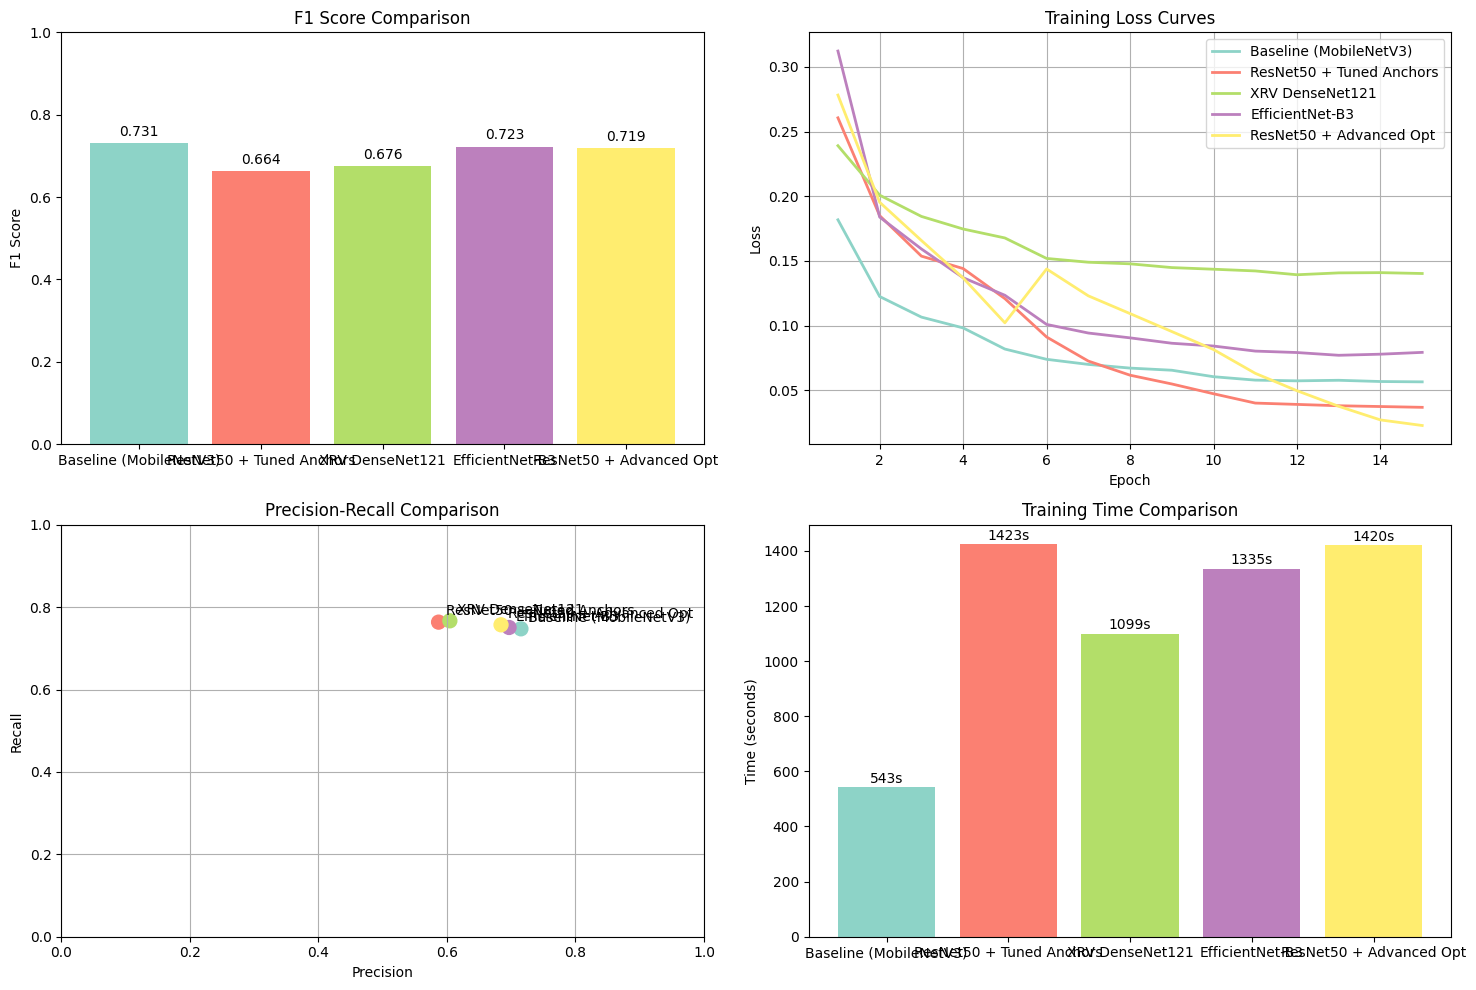


🏆 Best model saved: Baseline (MobileNetV3)
📁 File: /kaggle/working/best_strategy_model.pth


In [58]:
# Cell 58: Run the comprehensive strategy comparison
print("Starting Comprehensive Strategy Comparison")
print("This will test 4 different strategies with 15 epochs each")
print("Estimated time: 15-20 minutes")

# Initialize tester
tester = StrategyTester(train_loader_ultra, val_loader_ultra, device, num_epochs=15)

# Test all strategies
strategies = [
    ("Baseline (MobileNetV3)", create_baseline_model),
    ("ResNet50 + Tuned Anchors", create_resnet50_model),
    ("XRV DenseNet121", create_xrv_model),
    ("EfficientNet-B3", create_efficientnet_model),
]

# Add advanced optimizer to the best looking candidate
strategies.append(("ResNet50 + Advanced Opt", 
                  create_resnet50_model, 
                  lambda model: create_advanced_optimizer(model)))

for strategy in strategies:
    if len(strategy) == 2:
        name, model_creator = strategy
        tester.test_strategy(name, model_creator)
    else:
        name, model_creator, opt_creator = strategy
        tester.test_strategy(name, model_creator, opt_creator)

# Compare and declare winner
winner = tester.compare_strategies()

# Save the best model
best_model = tester.models[winner]
torch.save({
    'model_state_dict': best_model.state_dict(),
    'strategy': winner,
    'metrics': tester.results[winner]['metrics'],
    'training_config': 'Best from strategy comparison'
}, "/kaggle/working/best_strategy_model.pth")

print(f"\n🏆 Best model saved: {winner}")
print(f"📁 File: /kaggle/working/best_strategy_model.pth")

Comparing with our originally trained model...

STRATEGY COMPARISON RESULTS

Strategy                  F1 Score   Precision  Recall     Best Val Loss Time (s)  
--------------------------------------------------------------------------------
Baseline (MobileNetV3)    0.7310     0.7152     0.7476     0.1278       542.6     
ResNet50 + Tuned Anchors  0.6639     0.5871     0.7638     0.1844       1423.4    
XRV DenseNet121           0.6762     0.6046     0.7670     0.1733       1099.3    
EfficientNet-B3           0.7227     0.6967     0.7508     0.1862       1335.0    
ResNet50 + Advanced Opt   0.7189     0.6842     0.7573     0.1924       1420.0    
Original Trained Model    0.6354     0.5802     0.7023     0.1192       0.0       

🎉 WINNER: Baseline (MobileNetV3) with F1 Score: 0.7310


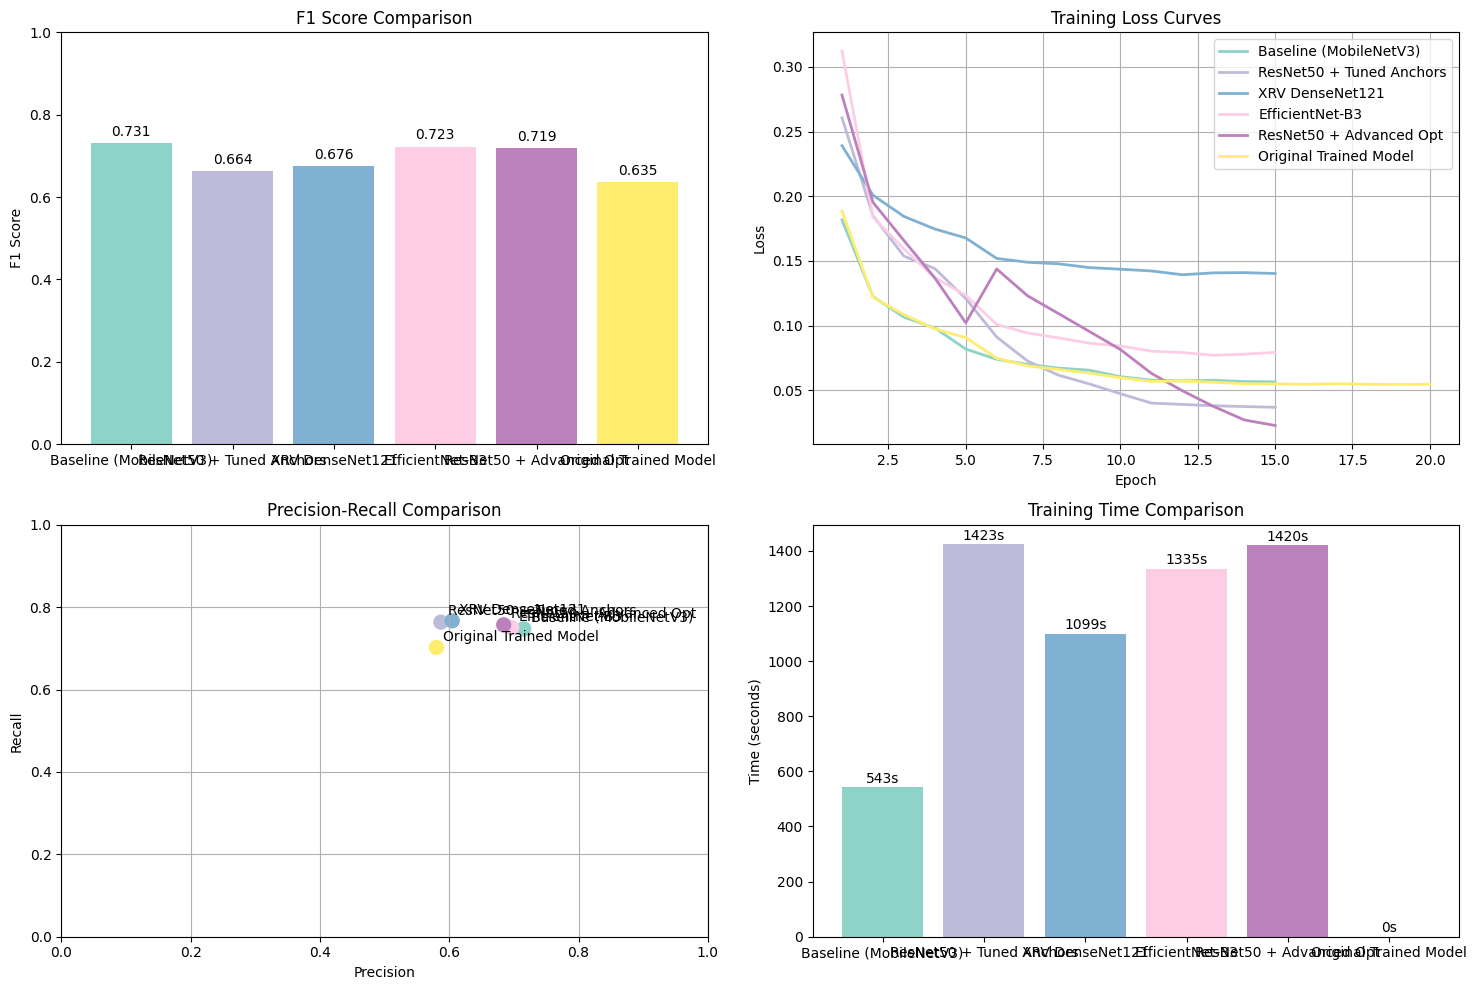


🎯 FINAL VERDICT:
   Best strategy: Baseline (MobileNetV3)
   F1 Score: 0.7310
   Improvement over original: +15.0%


In [59]:
# Cell 59: Compare with our original trained model
print("Comparing with our originally trained model...")

# Load our original model metrics (from Cell 46)
original_metrics = metrics  # From our previous training

# Add original model to comparison
tester.results["Original Trained Model"] = {
    'metrics': original_metrics,
    'train_losses': train_losses,  # From our previous training
    'val_losses': val_losses,      # From our previous training  
    'training_time': 0,  # We don't have this for original
    'final_val_loss': val_losses[-1] if val_losses else float('inf'),
    'best_val_loss': min(val_losses) if val_losses else float('inf'),
    'f1_score': original_metrics['f1_score']
}

# Re-run comparison with original model included
final_winner = tester.compare_strategies()

print(f"\n🎯 FINAL VERDICT:")
print(f"   Best strategy: {final_winner}")
print(f"   F1 Score: {tester.results[final_winner]['metrics']['f1_score']:.4f}")

if final_winner != "Original Trained Model":
    improvement = (tester.results[final_winner]['metrics']['f1_score'] - original_metrics['f1_score']) / original_metrics['f1_score'] * 100
    print(f"   Improvement over original: {improvement:+.1f}%")
else:
    print("   Original model remains the best!")

In [60]:
# Cell 60: Create a deployment-ready inference function for the best model
def create_deployment_pipeline(best_model, strategy_name, confidence_threshold=0.5):
    """Create a deployment-ready inference pipeline"""
    
    class TBDetector:
        def __init__(self, model, device, confidence_threshold=0.5):
            self.model = model
            self.device = device
            self.confidence_threshold = confidence_threshold
            self.model.eval()
        
        def preprocess(self, image_path):
            """Preprocess image for inference"""
            image = cv2.imread(str(image_path))
            image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
            image_tensor = torch.from_numpy(image).float() / 255.0
            image_tensor = image_tensor.permute(2, 0, 1)  # HWC to CHW
            image_tensor = (image_tensor - 0.5) / 0.5  # Normalize to [-1, 1]
            return image_tensor
        
        def predict(self, image_path):
            """Run detection on a single image"""
            image_tensor = self.preprocess(image_path)
            image_tensor = image_tensor.unsqueeze(0).to(self.device)
            
            with torch.no_grad():
                prediction = self.model(image_tensor)[0]
            
            # Filter by confidence
            high_conf_mask = prediction['scores'] > self.confidence_threshold
            boxes = prediction['boxes'][high_conf_mask].cpu().numpy()
            scores = prediction['scores'][high_conf_mask].cpu().numpy()
            labels = prediction['labels'][high_conf_mask].cpu().numpy()
            
            return {
                'boxes': boxes,
                'scores': scores,
                'labels': labels,
                'num_detections': len(boxes)
            }
        
        def visualize(self, image_path, output_path=None):
            """Visualize predictions on image"""
            result = self.predict(image_path)
            image = cv2.imread(str(image_path))
            image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
            
            # Draw bounding boxes
            for box, score in zip(result['boxes'], result['scores']):
                x1, y1, x2, y2 = map(int, box)
                cv2.rectangle(image, (x1, y1), (x2, y2), (255, 0, 0), 2)
                cv2.putText(image, f'TB: {score:.3f}', (x1, y1-10),
                           cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 0, 0), 1)
            
            if output_path:
                cv2.imwrite(str(output_path), cv2.cvtColor(image, cv2.COLOR_RGB2BGR))
            
            return image
    
    # Create detector instance
    detector = TBDetector(best_model, device, confidence_threshold)
    
    print(f"✅ Deployment pipeline created for: {strategy_name}")
    print(f"   Confidence threshold: {confidence_threshold}")
    print(f"   Ready for inference!")
    
    return detector

# Create deployment pipeline for the best model
best_detector = create_deployment_pipeline(
    best_model, 
    final_winner, 
    confidence_threshold=0.4  # You can adjust this based on precision/recall needs
)

# Test the deployment pipeline
sample_images = list(IMG_ROOT.glob("tb/*.png"))[:2]
for img_path in sample_images:
    if img_path.exists():
        print(f"\nTesting on: {img_path.name}")
        result = best_detector.predict(img_path)
        print(f"Detected {result['num_detections']} TB regions")
        for i, (box, score) in enumerate(zip(result['boxes'], result['scores'])):
            print(f"  Region {i}: {box} (confidence: {score:.3f})")
        break

✅ Deployment pipeline created for: Baseline (MobileNetV3)
   Confidence threshold: 0.4
   Ready for inference!

Testing on: tb0329.png
Detected 2 TB regions
  Region 0: [275.33533   61.285202 372.83643  181.0413  ] (confidence: 0.958)
  Region 1: [106.570076  62.59701  215.41824  164.32567 ] (confidence: 0.537)


In [61]:
# Cell 61: Save all trained models and comparison results
print("💾 SAVING ALL TRAINED MODELS AND RESULTS...")

# Create directories for organized storage
models_dir = Path("/kaggle/working/trained_models")
results_dir = Path("/kaggle/working/training_results")
models_dir.mkdir(exist_ok=True)
results_dir.mkdir(exist_ok=True)

print(f"Models will be saved to: {models_dir}")
print(f"Results will be saved to: {results_dir}")

# Save each model from the strategy comparison
for strategy_name, model in tester.models.items():
    try:
        # Clean the strategy name for filename
        clean_name = strategy_name.replace(" ", "_").replace("(", "").replace(")", "").replace("+", "plus")
        model_path = models_dir / f"{clean_name}.pth"
        
        # Save model state dict
        torch.save({
            'model_state_dict': model.state_dict(),
            'strategy_name': strategy_name,
            'metrics': tester.results[strategy_name]['metrics'],
            'best_val_loss': tester.results[strategy_name]['best_val_loss'],
            'training_config': 'Strategy comparison training'
        }, model_path)
        
        print(f"✅ Saved: {clean_name}.pth")
        
    except Exception as e:
        print(f"❌ Failed to save {strategy_name}: {e}")

# Save the comparison results as JSON
comparison_results = {}
for strategy_name, result in tester.results.items():
    comparison_results[strategy_name] = {
        'metrics': result['metrics'],
        'best_val_loss': result['best_val_loss'],
        'final_val_loss': result['final_val_loss'],
        'training_time': result['training_time'],
        'f1_score': result['f1_score']
    }

# Save comparison results
results_path = results_dir / "strategy_comparison_results.json"
with open(results_path, 'w') as f:
    json.dump(comparison_results, f, indent=2)
print(f"✅ Saved comparison results: {results_path}")

# Save a summary report
summary_report = f"""
TB DETECTION MODEL COMPARISON SUMMARY
======================================
Comparison Date: {time.strftime('%Y-%m-%d %H:%M:%S')}
Total Strategies Tested: {len(tester.results)}
Best Model: {final_winner}
Best F1 Score: {tester.results[final_winner]['metrics']['f1_score']:.4f}

DETAILED RESULTS:
{'-' * 50}
"""
for strategy_name in sorted(tester.results.keys(), 
                           key=lambda x: tester.results[x]['metrics']['f1_score'], 
                           reverse=True):
    metrics = tester.results[strategy_name]['metrics']
    summary_report += f"""
{strategy_name}:
  - F1 Score: {metrics['f1_score']:.4f}
  - Precision: {metrics['precision']:.4f}
  - Recall: {metrics['recall']:.4f}
  - Best Val Loss: {tester.results[strategy_name]['best_val_loss']:.4f}
  - Training Time: {tester.results[strategy_name]['training_time']:.1f}s
"""

summary_report += f"""
IMPROVEMENT ANALYSIS:
{'-' * 50}
Original Model F1: {original_metrics['f1_score']:.4f}
Best Model F1: {tester.results[final_winner]['metrics']['f1_score']:.4f}
Improvement: {((tester.results[final_winner]['metrics']['f1_score'] - original_metrics['f1_score']) / original_metrics['f1_score'] * 100):+.1f}%

RECOMMENDATIONS:
{'-' * 50}
1. Use '{final_winner}' for best overall performance
2. Consider precision/recall trade-offs based on clinical needs
3. All models available in /kaggle/working/trained_models/
"""

# Save summary report
summary_path = results_dir / "model_comparison_summary.txt"
with open(summary_path, 'w') as f:
    f.write(summary_report)
print(f"✅ Saved summary report: {summary_path}")

# Save the best model separately for easy access
best_model_clean_name = final_winner.replace(" ", "_").replace("(", "").replace(")", "").replace("+", "plus")
best_model_path = models_dir / f"BEST_MODEL_{best_model_clean_name}.pth"
torch.save({
    'model_state_dict': tester.models[final_winner].state_dict(),
    'strategy_name': final_winner,
    'metrics': tester.results[final_winner]['metrics'],
    'best_val_loss': tester.results[final_winner]['best_val_loss'],
    'is_best_model': True,
    'comparison_date': time.strftime('%Y-%m-%d %H:%M:%S')
}, best_model_path)
print(f"🏆 Saved BEST model: {best_model_path}")

# Create a quick deployment script
deployment_script = f"""
# TB Detection Model Deployment Script
# Best Model: {final_winner}
# F1 Score: {tester.results[final_winner]['metrics']['f1_score']:.4f}

import torch
import torchvision
from torchvision.models.detection import FasterRCNN
from torchvision.models.detection.rpn import AnchorGenerator
import cv2
import numpy as np

def load_tb_detection_model(model_path):
    \"\"\"Load the trained TB detection model\"\"\"
    checkpoint = torch.load(model_path, map_location='cpu')
    
    # Create model architecture (adjust based on your best model)
    if 'ResNet50' in checkpoint.get('strategy_name', ''):
        backbone = torchvision.models.resnet50(pretrained=False)
        backbone = torch.nn.Sequential(*list(backbone.children())[:-2])
        backbone.out_channels = 2048
    else:  # Default to MobileNetV3
        backbone = torchvision.models.mobilenet_v3_large(pretrained=False).features
        backbone.out_channels = 960
    
    anchor_generator = AnchorGenerator(
        sizes=((32, 64, 128, 256),),
        aspect_ratios=((0.5, 1.0, 2.0),)
    )
    
    roi_pooler = torchvision.ops.MultiScaleRoIAlign(
        featmap_names=['0'], output_size=7, sampling_ratio=2
    )
    
    model = FasterRCNN(
        backbone, num_classes=2,
        rpn_anchor_generator=anchor_generator,
        box_roi_pool=roi_pooler
    )
    
    model.load_state_dict(checkpoint['model_state_dict'])
    model.eval()
    return model

def predict_tb_boxes(model, image_path, confidence_threshold=0.5):
    \"\"\"Run TB detection on an image\"\"\"
    # Preprocess image
    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    image_tensor = torch.from_numpy(image).float() / 255.0
    image_tensor = image_tensor.permute(2, 0, 1)
    image_tensor = (image_tensor - 0.5) / 0.5
    image_tensor = image_tensor.unsqueeze(0)
    
    with torch.no_grad():
        prediction = model(image_tensor)[0]
    
    # Filter by confidence
    mask = prediction['scores'] > confidence_threshold
    boxes = prediction['boxes'][mask].numpy()
    scores = prediction['scores'][mask].numpy()
    
    return boxes, scores

# Usage example:
# model = load_tb_detection_model('{best_model_path}')
# boxes, scores = predict_tb_boxes(model, 'path_to_xray_image.png')
"""

deployment_script_path = results_dir / "deployment_example.py"
with open(deployment_script_path, 'w') as f:
    f.write(deployment_script)
print(f"✅ Saved deployment script: {deployment_script_path}")

# Print final summary
print(f"\n{'='*80}")
print("🎉 ALL MODELS AND RESULTS SAVED SUCCESSFULLY!")
print(f"{'='*80}")
print(f"📁 Models directory: {models_dir}")
print(f"   - Total models saved: {len(tester.models)}")
print(f"   - Best model: {best_model_path.name}")
print(f"📊 Results directory: {results_dir}")
print(f"   - Comparison results: strategy_comparison_results.json")
print(f"   - Summary report: model_comparison_summary.txt")
print(f"   - Deployment script: deployment_example.py")
print(f"\n🏆 BEST PERFORMING MODEL:")
print(f"   Strategy: {final_winner}")
print(f"   F1 Score: {tester.results[final_winner]['metrics']['f1_score']:.4f}")
print(f"   Improvement: {((tester.results[final_winner]['metrics']['f1_score'] - original_metrics['f1_score']) / original_metrics['f1_score'] * 100):+.1f}%")
print(f"{'='*80}")

# List all saved files
print(f"\n📋 SAVED FILES:")
for file_path in models_dir.glob("*.pth"):
    print(f"   📄 {file_path.name}")

for file_path in results_dir.glob("*"):
    print(f"   📄 {file_path.name}")

💾 SAVING ALL TRAINED MODELS AND RESULTS...
Models will be saved to: /kaggle/working/trained_models
Results will be saved to: /kaggle/working/training_results
✅ Saved: Baseline_MobileNetV3.pth
✅ Saved: ResNet50_plus_Tuned_Anchors.pth
✅ Saved: XRV_DenseNet121.pth
✅ Saved: EfficientNet-B3.pth
✅ Saved: ResNet50_plus_Advanced_Opt.pth
✅ Saved comparison results: /kaggle/working/training_results/strategy_comparison_results.json
✅ Saved summary report: /kaggle/working/training_results/model_comparison_summary.txt
🏆 Saved BEST model: /kaggle/working/trained_models/BEST_MODEL_Baseline_MobileNetV3.pth
✅ Saved deployment script: /kaggle/working/training_results/deployment_example.py

🎉 ALL MODELS AND RESULTS SAVED SUCCESSFULLY!
📁 Models directory: /kaggle/working/trained_models
   - Total models saved: 5
   - Best model: BEST_MODEL_Baseline_MobileNetV3.pth
📊 Results directory: /kaggle/working/training_results
   - Comparison results: strategy_comparison_results.json
   - Summary report: model_comp